In [ ]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import locale
import re

In [ ]:
#Para mostrar todas as linha e colunas do dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
#Carregar dataframe
state_of_data = pd.read_csv("/content/State_of_data_BR_2023_Kaggle - df_survey_2023.csv")

In [ ]:
#Selecionar as colunas que serão usadas
colunas = ["('P1_a ', 'Idade')", "('P1_a_1 ', 'Faixa idade')", "('P1_b ', 'Genero')", "('P1_c ', 'Cor/raca/etnia')", "('P1_d ', 'PCD')", "('P1_i ', 'Estado onde mora')", "('P1_i_1 ', 'uf onde mora')", "('P1_i_2 ', 'Regiao onde mora')", "('P1_j ', 'Mudou de Estado?')", "('P1_k ', 'Regiao de origem')", "('P1_l ', 'Nivel de Ensino')", "('P1_m ', 'Área de Formação')", "('P2_a ', 'Qual sua situação atual de trabalho?')", "('P2_b ', 'Setor')", "('P2_c ', 'Numero de Funcionarios')", "('P2_f ', 'Cargo Atual')", "('P2_g ', 'Nivel')", "('P2_h ', 'Faixa salarial')", "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')", "('P2_r ', 'Atualmente qual a sua forma de trabalho?')", "('P3_b ', 'Quais desses papéis/cargos fazem parte do time (ou chapter) de dados da sua empresa?')", "('P3_b_1 ', 'Analytics Engineer')", "('P3_b_2 ', 'Engenharia de Dados/Data Engineer')", "('P3_b_3 ', 'Analista de Dados/Data Analyst')", "('P3_b_4 ', 'Cientista de Dados/Data Scientist')", "('P3_b_5 ', 'Database Administrator/DBA')", "('P3_b_6 ', 'Analista de Business Intelligence/BI')", "('P3_b_7 ', 'Arquiteto de Dados/Data Architect')", "('P3_b_8 ', 'Data Product Manager/DPM')", "('P3_b_9 ', 'Business Analyst')", "('P4_d_1 ', 'SQL')", "('P4_d_2 ', 'R ')", "('P4_d_3 ', 'Python')", "('P4_d_4 ', 'C/C++/C#')", "('P4_d_5 ', '.NET')", "('P4_d_6 ', 'Java')", "('P4_d_7 ', 'Julia')", "('P4_d_8 ', 'SAS/Stata')", "('P4_d_9 ', 'Visual Basic/VBA')", "('P4_d_10 ', 'Scala')", "('P4_d_11 ', 'Matlab')", "('P4_d_12 ', 'Rust')", "('P4_d_13 ', 'PHP')", "('P4_d_14 ', 'JavaScript')", "('P4_d_15 ', 'Não utilizo nenhuma linguagem')", "('P4_h_1 ', 'Azure (Microsoft)')", "('P4_h_2 ', 'Amazon Web Services (AWS)')", "('P4_h_3 ', 'Google Cloud (GCP)')", "('P4_h_4 ', 'Oracle Cloud')", "('P4_h_5 ', 'IBM')", "('P4_h_6 ', 'Servidores On Premise/Não utilizamos Cloud')", "('P4_h_7 ', 'Cloud Própria')", "('P4_j_1 ', 'Microsoft PowerBI')", "('P4_j_2 ', 'Qlik View/Qlik Sense')", "('P4_j_3 ', 'Tableau')", "('P4_j_4 ', 'Metabase')", "('P4_j_5 ', 'Superset')", "('P4_j_6 ', 'Redash')", "('P4_j_7 ', 'Looker')", "('P4_j_8 ', 'Looker Studio(Google Data Studio)')", "('P4_j_9 ', 'Amazon Quicksight')", "('P4_j_10 ', 'Mode')", "('P4_j_11 ', 'Alteryx')", "('P4_j_12 ', 'MicroStrategy')", "('P4_j_13 ', 'IBM Analytics/Cognos')", "('P4_j_14 ', 'SAP Business Objects/SAP Analytics')", "('P4_j_15 ', 'Oracle Business Intelligence')", "('P4_j_16 ', 'Salesforce/Einstein Analytics')", "('P4_j_17 ', 'Birst')", "('P4_j_18 ', 'SAS Visual Analytics')", "('P4_j_19 ', 'Grafana')", "('P4_j_20 ', 'TIBCO Spotfire')", "('P4_j_21 ', 'Pentaho')", "('P4_j_22 ', 'Fazemos todas as análises utilizando apenas Excel ou planilhas do google')", "('P4_j_23 ', 'Não utilizo nenhuma ferramenta de BI no trabalho')"]

In [ ]:
#Deixar o dataset apenas com as colunas selecionadas
state_of_data_tr = state_of_data[colunas]

In [ ]:
#Renomear as colunas do dataset
state_of_data_tr = state_of_data_tr.rename(columns={"('P1_a ', 'Idade')": "Idade", "('P1_a_1 ', 'Faixa idade')": "Faixa de idade", "('P1_b ', 'Genero')": "Genero", "('P1_c ', 'Cor/raca/etnia')": "Cor/Raça/Etnia", "('P1_d ', 'PCD')": "PDC", "('P1_i ', 'Estado onde mora')": "Estado_onde_mora", "('P1_i_1 ', 'uf onde mora')": "Uf", "('P1_i_2 ', 'Regiao onde mora')": "Regiao_onde_mora", "('P1_j ', 'Mudou de Estado?')": "Mudou_de_estado", "('P1_k ', 'Regiao de origem')": "Regiao_de_Origem", "('P1_l ', 'Nivel de Ensino')": "Nivel_de_Ensino", "('P1_m ', 'Área de Formação')": "Area_de_Formacao", "('P2_a ', 'Qual sua situação atual de trabalho?')": "Situacao_atual_de_trabalho", "('P2_b ', 'Setor')": "Setor", "('P2_c ', 'Numero de Funcionarios')": "Num_func_empresa_que_trabalha", "('P2_f ', 'Cargo Atual')": "Cargo_Atual", "('P2_g ', 'Nivel')": "Nível", "('P2_h ', 'Faixa salarial')": "Faixa_Salarial", "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')": "Tempo_de_experiencia_na_area_de_dados", "('P2_r ', 'Atualmente qual a sua forma de trabalho?')": "Atual_forma_de_trabalho", "('P3_b ', 'Quais desses papéis/cargos fazem parte do time (ou chapter) de dados da sua empresa?')": "Papeis/cargos_do_time/chapter_de_dados", "('P3_b_1 ', 'Analytics Engineer')": "Analytics_Engineer", "('P3_b_2 ', 'Engenharia de Dados/Data Engineer')": "Engenharia_de_Dados/Data_Engineer", "('P3_b_3 ', 'Analista de Dados/Data Analyst')": "Analista_de_Dados/Data_Analyst", "('P3_b_4 ', 'Cientista de Dados/Data Scientist')": "Cientista_de_Dados/Data_Scientist", "('P3_b_5 ', 'Database Administrator/DBA')": "Database_Administrator/DBA", "('P3_b_6 ', 'Analista de Business Intelligence/BI')": "Analista_de_Business_Intelligence/BI", "('P3_b_7 ', 'Arquiteto de Dados/Data Architect')": "Arquiteto_de_Dados/Data_Architect", "('P3_b_8 ', 'Data Product Manager/DPM')": "Data_Product_Manager/DPM", "('P3_b_9 ', 'Business Analyst')": "Business_Analyst", "('P4_d_1 ', 'SQL')": "SQL", "('P4_d_2 ', 'R ')": "R", "('P4_d_3 ', 'Python')": "Python", "('P4_d_4 ', 'C/C++/C#')": "C/C++/C#", "('P4_d_5 ', '.NET')": "NET", "('P4_d_6 ', 'Java')": "Java", "('P4_d_7 ', 'Julia')": "Julia", "('P4_d_8 ', 'SAS/Stata')": "SAS/Stata", "('P4_d_9 ', 'Visual Basic/VBA')": "Visual Basic/VBA", "('P4_d_10 ', 'Scala')": "Scala", "('P4_d_11 ', 'Matlab')": "Matlab", "('P4_d_12 ', 'Rust')": "Rust", "('P4_d_13 ', 'PHP')": "PHP", "('P4_d_14 ', 'JavaScript')": "JavaScript", "('P4_d_15 ', 'Não utilizo nenhuma linguagem')": "Não utilizo nenhuma linguagem", "('P4_h_1 ', 'Azure (Microsoft)')": "Azure (Microsoft)", "('P4_h_2 ', 'Amazon Web Services (AWS)')": "Amazon Web Services (AWS)", "('P4_h_3 ', 'Google Cloud (GCP)')": "Google Cloud (GCP)", "('P4_h_4 ', 'Oracle Cloud')": "Oracle Cloud", "('P4_h_5 ', 'IBM')": "IBM", "('P4_h_6 ', 'Servidores On Premise/Não utilizamos Cloud')": "Servidores On Premise/Não utilizamos Cloud", "('P4_h_7 ', 'Cloud Própria')": "Cloud Própria", "('P4_j_1 ', 'Microsoft PowerBI')": "Microsoft PowerBI", "('P4_j_2 ', 'Qlik View/Qlik Sense')": "Qlik View/Qlik Sense", "('P4_j_3 ', 'Tableau')": "Tableau", "('P4_j_4 ', 'Metabase')": "Metabase", "('P4_j_5 ', 'Superset')": "Superset", "('P4_j_6 ', 'Redash')": "Redash", "('P4_j_7 ', 'Looker')": "Looker", "('P4_j_8 ', 'Looker Studio(Google Data Studio)')": "Looker Studio(Google Data Studio)", "('P4_j_9 ', 'Amazon Quicksight')": "Amazon Quicksight", "('P4_j_10 ', 'Mode')": "Mode", "('P4_j_11 ', 'Alteryx')": "Alteryx", "('P4_j_12 ', 'MicroStrategy')": "MicroStrategy", "('P4_j_13 ', 'IBM Analytics/Cognos')": "IBM Analytics/Cognos", "('P4_j_14 ', 'SAP Business Objects/SAP Analytics')": "SAP Business Objects/SAP Analytics", "('P4_j_15 ', 'Oracle Business Intelligence')": "Oracle Business Intelligence", "('P4_j_16 ', 'Salesforce/Einstein Analytics')": "Salesforce/Einstein Analytics", "('P4_j_17 ', 'Birst')": "Birst", "('P4_j_18 ', 'SAS Visual Analytics')": "SAS Visual Analytics", "('P4_j_19 ', 'Grafana')": "Grafana", "('P4_j_20 ', 'TIBCO Spotfire')": "TIBCO Spotfire", "('P4_j_21 ', 'Pentaho')": "Pentaho", "('P4_j_22 ', 'Fazemos todas as análises utilizando apenas Excel ou planilhas do google')": "Fazemos todas as análises utilizando apenas Excel ou planilhas do google", "('P4_j_23 ', 'Não utilizo nenhuma ferramenta de BI no trabalho')": "Não utilizo nenhuma ferramenta de BI no trabalho"})

In [ ]:
#Criar as colunas de salário minimo, máximo e médio.

def extrair_salarios(faixa):
    # Se o valor não for string (por exemplo, NaN), retorna None para todos
    if not isinstance(faixa, str):
        return None, None, None

    try:
        # Encontra todos os números na string (incluindo decimais)
        valores = re.findall(r'R\$\s*(\d+[\.,]?\d*)', faixa)

        # Converte para float (substituindo vírgula por ponto se necessário)
        salarios = [float(valor.replace('.', '').replace(',', '.')) for valor in valores]

        if len(salarios) >= 2:
            sal_min = salarios[0]
            sal_max = salarios[1]
            sal_medio = (sal_min + sal_max) / 2
        elif len(salarios) == 1:
            # Caso tenha apenas um valor (ex: "Acima de R$ X")
            sal_min = salarios[0]
            sal_max = None
            sal_medio = None
        else:
            sal_min = sal_max = sal_medio = None

        return sal_min, sal_max, sal_medio
    except:
        return None, None, None

# Aplicando a função ao dataframe
state_of_data_tr[['Salario_Minimo', 'Salario_Maximo', 'Salario_Medio']] = (
    state_of_data_tr['Faixa_Salarial']
    .apply(lambda x: pd.Series(extrair_salarios(x)))
)

# Mostrando o resultado
print(state_of_data_tr[['Faixa_Salarial', 'Salario_Minimo', 'Salario_Maximo', 'Salario_Medio']].head())

                     Faixa_Salarial  Salario_Minimo  Salario_Maximo  \
0  de R$ 12.001/mês a R$ 16.000/mês         12001.0         16000.0   
1    de R$ 6.001/mês a R$ 8.000/mês          6001.0          8000.0   
2    de R$ 6.001/mês a R$ 8.000/mês          6001.0          8000.0   
3                               NaN             NaN             NaN   
4    de R$ 4.001/mês a R$ 6.000/mês          4001.0          6000.0   

   Salario_Medio  
0        14000.5  
1         7000.5  
2         7000.5  
3            NaN  
4         5000.5  


In [ ]:
#Reordenar as colunas do dataset
state_of_data_tr = state_of_data_tr[["Idade", "Faixa de idade", "Genero", "Cor/Raça/Etnia", "PDC", "Estado_onde_mora", "Uf", "Regiao_onde_mora", "Mudou_de_estado", "Regiao_de_Origem", "Nivel_de_Ensino", "Area_de_Formacao", "Situacao_atual_de_trabalho", "Setor", "Num_func_empresa_que_trabalha", "Cargo_Atual",  "Nível",  "Faixa_Salarial", "Salario_Minimo", "Salario_Maximo", "Salario_Medio", "Tempo_de_experiencia_na_area_de_dados", "Atual_forma_de_trabalho", "Papeis/cargos_do_time/chapter_de_dados", "Analytics_Engineer", "Engenharia_de_Dados/Data_Engineer", "Analista_de_Dados/Data_Analyst", "Cientista_de_Dados/Data_Scientist", "Database_Administrator/DBA", "Analista_de_Business_Intelligence/BI", "Arquiteto_de_Dados/Data_Architect", "Data_Product_Manager/DPM", "Business_Analyst", "SQL", "R", "Python", "C/C++/C#", "NET", "Java", "Julia", "SAS/Stata", "Visual Basic/VBA", "Scala", "Matlab", "Rust", "PHP", "JavaScript", "Não utilizo nenhuma linguagem", "Azure (Microsoft)", "Amazon Web Services (AWS)", "Google Cloud (GCP)", "Oracle Cloud", "IBM", "Servidores On Premise/Não utilizamos Cloud", "Cloud Própria", "Microsoft PowerBI", "Qlik View/Qlik Sense", "Tableau", "Metabase", "Superset", "Redash", "Looker", "Looker Studio(Google Data Studio)", "Amazon Quicksight", "Mode", "Alteryx", "MicroStrategy", "IBM Analytics/Cognos", "SAP Business Objects/SAP Analytics", "Oracle Business Intelligence", "Salesforce/Einstein Analytics", "Birst", "SAS Visual Analytics", "Grafana", "TIBCO Spotfire", "Pentaho", "Fazemos todas as análises utilizando apenas Excel ou planilhas do google", "Não utilizo nenhuma ferramenta de BI no trabalho"]]

In [ ]:
#Abrir a tabela IDH
idh = pd.read_excel("/content/Tabela_idh_ajus.xls")

In [ ]:
#Abrir a tabela PIB
pib = pd.read_excel("/content/Pib2021.xlsx")

In [ ]:
#Unir as tabelas IDH e PIB atravez da coluna UF. Novo dataset chama-se merged_df
merged_df = state_of_data_tr.merge(
    idh,
    on='Uf',
    how='left'
).merge(
    pib,
    on='Uf',
    how='left'
)

print(merged_df.head())

   Idade Faixa de idade     Genero Cor/Raça/Etnia  PDC     Estado_onde_mora  \
0     31          30-34  Masculino         Branca  Não    Minas Gerais (MG)   
1     30          30-34  Masculino         Branca  Não  Espírito Santo (ES)   
2     37          35-39   Feminino        Amarela  Não       São Paulo (SP)   
3     22          22-24  Masculino          Preta  Não       São Paulo (SP)   
4     34          30-34  Masculino         Branca  Não    Minas Gerais (MG)   

   Uf Regiao_onde_mora  Mudou_de_estado Regiao_de_Origem  \
0  MG          Sudeste              1.0              NaN   
1  ES          Sudeste              1.0              NaN   
2  SP          Sudeste              1.0              NaN   
3  SP          Sudeste              1.0              NaN   
4  MG          Sudeste              1.0              NaN   

          Nivel_de_Ensino                                   Area_de_Formacao  \
0        Doutorado ou Phd  Computação / Engenharia de Software / Sistemas...   
1   

In [ ]:
State_idh_pib = merged_df

In [ ]:
#from google.colab import files

# Gera o arquivo CSV (sem índices e com encoding para caracteres especiais)
#State_idh_pib.to_csv('State_idh_pib.csv', index=False, encoding='utf-8-sig')

# Inicia o download automático para seu computador
#files.download('State_idh_pib.csv')

In [ ]:
merged_df['Faixa_Salarial'].unique()

array(['de R$ 12.001/mês a R$ 16.000/mês',
       'de R$ 6.001/mês a R$ 8.000/mês', nan,
       'de R$ 4.001/mês a R$ 6.000/mês',
       'de R$ 8.001/mês a R$ 12.000/mês',
       'de R$ 20.001/mês a R$ 25.000/mês',
       'de R$ 1.001/mês a R$ 2.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
       'de R$ 16.001/mês a R$ 20.000/mês',
       'de R$ 2.001/mês a R$ 3.000/mês', 'Acima de R$ 40.001/mês',
       'de R$ 25.001/mês a R$ 30.000/mês', 'Menos de R$ 1.000/mês',
       'de R$ 30.001/mês a R$ 40.000/mês', 'de R$ 101/mês a R$ 2.000/mês'],
      dtype=object)

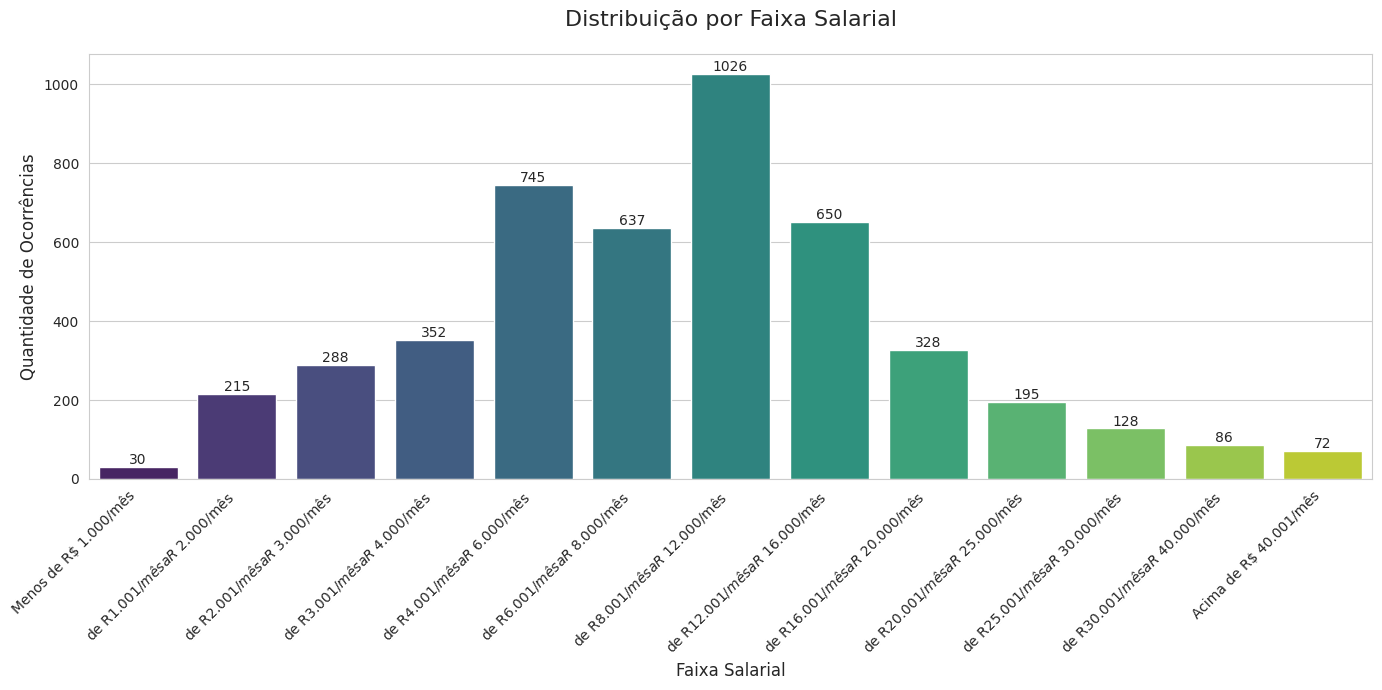

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Definir a ordem correta das faixas salariais
ordem_faixas = [
    'Menos de R$ 1.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]

# Converter para categoria ordenada e tratar NaN
merged_df['Faixa_Salarial'] = pd.Categorical(
    merged_df['Faixa_Salarial'],
    categories=ordem_faixas,
    ordered=True
)

# Contar ocorrências de cada faixa
contagem = merged_df['Faixa_Salarial'].value_counts().sort_index()

# Configurar estilo do Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

# Criar gráfico de barras com Seaborn - usando cor 'skyblue'
ax = sns.barplot(
    x=contagem.index,
    y=contagem.values,
    palette="viridis",  # Altere para qualquer paleta do Seaborn (ex: "rocket", "mako", "flare")
    hue=contagem.index,  # Para diferenciar as cores
    legend=False,       # Remover legenda redundante
    dodge=False         # Evitar separação das barras
)

# Personalizar o gráfico
plt.title('Distribuição por Faixa Salarial', fontsize=16, pad=20)
plt.xlabel('Faixa Salarial', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adicionar valores nas barras
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# Verificar valores únicos da coluna "Faixa de idade"
valores_unicos = merged_df['Faixa de idade'].unique()

# Exibir os valores únicos
print("Valores únicos na coluna 'Faixa de idade':")
print(valores_unicos)

Valores únicos na coluna 'Faixa de idade':
['30-34' '35-39' '22-24' '25-29' '45-49' '40-44' '50-54' '55+' '17-21']


<ipython-input-28-1ee64863db0e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


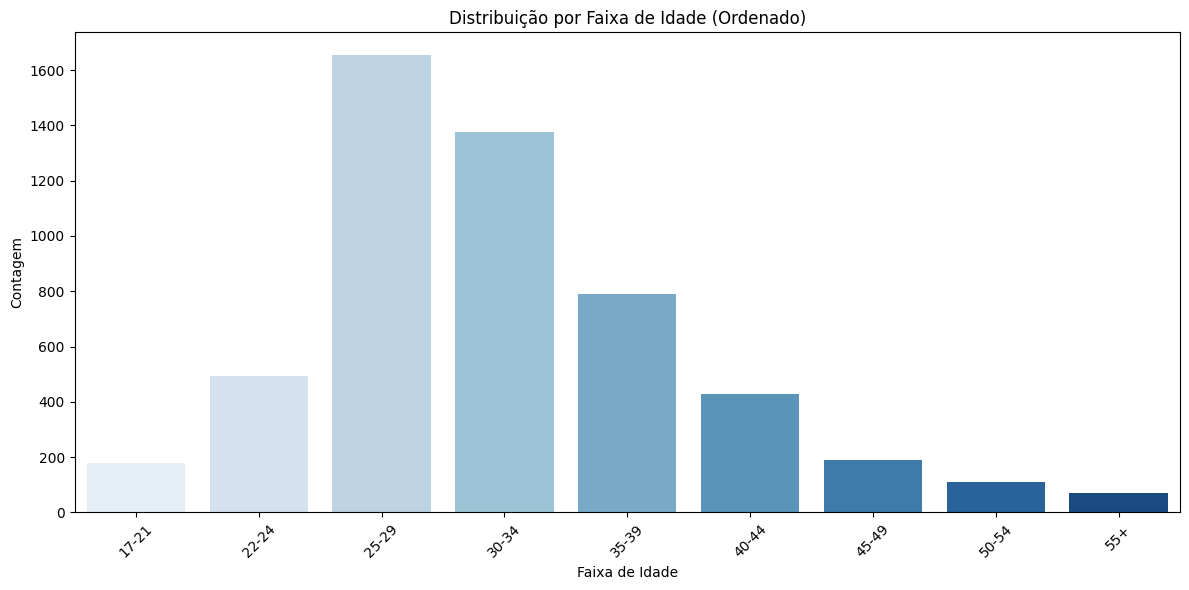

In [ ]:

# Definir a ordem correta das faixas etárias
ordem_faixas = ['17-21', '22-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55+']

# Plotar o gráfico de barras (não histograma, pois são categorias)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=merged_df,
    x='Faixa de idade',
    order=ordem_faixas,  # Força a ordem correta
    palette='Blues'
)

# Ajustes estéticos
plt.title('Distribuição por Faixa de Idade (Ordenado)')
plt.xlabel('Faixa de Idade')
plt.ylabel('Contagem')
plt.xticks(rotation=45)  # Rotaciona rótulos se necessário

plt.tight_layout()  # Evita cortes nos rótulos
plt.show()

In [ ]:
# Retorna a quantidade de NaN em cada coluna
merged_df.isna().sum()

,0
Idade,0
Faixa de idade,0
Genero,0
Cor/Raça/Etnia,0
PDC,0
Estado_onde_mora,121
Uf,124
Regiao_onde_mora,124
Mudou_de_estado,121
Regiao_de_Origem,4229


In [ ]:
#Verificação de valores únicos para plotar grafico
valores_unicos = merged_df['Num_func_empresa_que_trabalha'].unique()
print(valores_unicos)

['Acima de 3.000' 'de 101 a 500' nan 'de 51 a 100' 'de 501 a 1.000'
 'de 11 a 50' 'de 1.001 a 3.000' 'de 6 a 10' 'de 1 a 5' 'de 501 a 100']


<ipython-input-17-dde8b1eec2cd>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-17-dde8b1eec2cd>:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(largura)} ({percentuais[i]}%)',


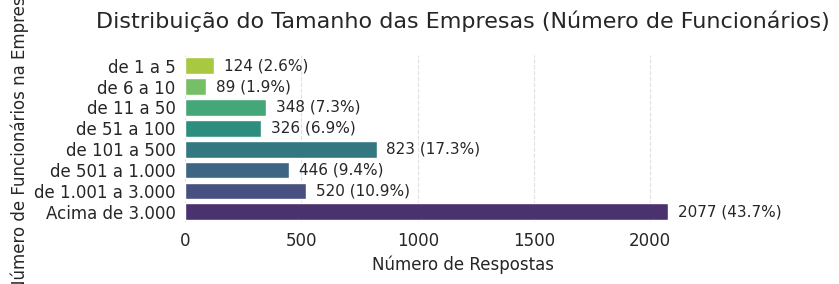

In [ ]:
#Plotagem do grafico Distribuição do Tamanho das Empresas (Número de Funcionários)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurações do gráfico
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Definir a ordem CRESCENTE das categorias (do menor para o maior tamanho)
ordem_tamanho = [
    'de 1 a 5',
    'de 6 a 10',
    'de 11 a 50',
    'de 51 a 100',
    'de 101 a 500',
    'de 501 a 1.000',
    'de 1.001 a 3.000',
    'Acima de 3.000'
]

# Nota: Há uma categoria 'de 501 a 100' que parece ser um erro (deveria ser 'de 501 a 1.000'?)
# Vamos assumir que é um erro de digitação e agrupar com 'de 501 a 1.000'
merged_df['Num_func_empresa_agrupado'] = merged_df['Num_func_empresa_que_trabalha'].replace(
    {'de 501 a 100': 'de 501 a 1.000'}
)

# Filtrar NaN e manter apenas as categorias definidas
dados_filtrados = merged_df['Num_func_empresa_agrupado'].dropna()
dados_filtrados = dados_filtrados[dados_filtrados.isin(ordem_tamanho)]

# Criar o gráfico de barras horizontais
ax = sns.countplot(
    y='Num_func_empresa_agrupado',
    data=merged_df,
    order=ordem_tamanho,  # Ordem crescente definida
    palette='viridis_r',  # Paleta de cores (reversa para cores mais escuras = maior tamanho)
    orient='h'
)

# Calcular totais e percentuais
total_validos = len(dados_filtrados)
contagens = dados_filtrados.value_counts().reindex(ordem_tamanho)
percentuais = (contagens / total_validos * 100).round(1)

# Adicionar rótulos com contagens e percentuais
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    ax.text(
        largura + 0.02 * contagens.max(),  # Margem de 2% do valor máximo
        p.get_y() + p.get_height()/2,
        f'{int(largura)} ({percentuais[i]}%)',
        va='center',
        ha='left',
        fontsize=11
    )

# Customização do gráfico
plt.title('Distribuição do Tamanho das Empresas (Número de Funcionários)', fontsize=16, pad=20)
plt.xlabel('Número de Respostas', fontsize=12)
plt.ylabel('Número de Funcionários na Empresa', fontsize=12)
plt.xlim(right=contagens.max() * 1.15)  # Ajuste do limite do eixo X

# Remover bordas e adicionar grid
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#Verificação de valores únicos para plotar grafico
valores_unicos = merged_df['Cargo_Atual'].unique()
print(valores_unicos)

['Cientista de Dados/Data Scientist' 'Analista de BI/BI Analyst'
 'Analista de Dados/Data Analyst' nan
 'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect'
 'Analista de Negócios/Business Analyst' 'Outra Opção'
 'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas'
 'Professor/Pesquisador' 'Analytics Engineer' 'Economista' 'Estatístico'
 'Analista de Suporte/Analista Técnico'
 'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)'
 'Outras Engenharias (não inclui dev)'
 'Analista de Inteligência de Mercado/Market Intelligence'
 'Engenheiro de Machine Learning/ML Engineer/AI Engineer'
 'DBA/Administrador de Banco de Dados']


<ipython-input-19-eec8d968224f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-19-eec8d968224f>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(largura)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"


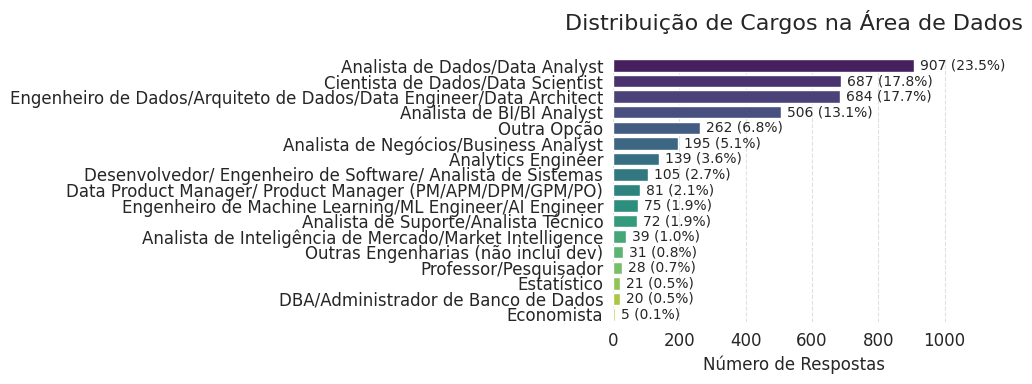

In [ ]:
#Plotagem do grafico Distribuição de Cargos na Área de Dados
# Configurações do gráfico
plt.figure(figsize=(10, 4))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Filtrar NaN e calcular contagens
dados_filtrados = merged_df['Cargo_Atual'].dropna()
contagens = dados_filtrados.value_counts()

# Ordem decrescente baseada nas contagens
ordem_decrescente = contagens.index.tolist()  # Já está em ordem decrescente por padrão do value_counts()

# Criar gráfico de barras horizontais
ax = sns.countplot(
    y='Cargo_Atual',
    data=merged_df,
    order=ordem_decrescente,  # Ordem decrescente
    palette='viridis',
    orient='h'
)

# Calcular percentuais
total_respostas = len(dados_filtrados)
percentuais = (contagens / total_respostas * 100).round(1)

# Adicionar rótulos com contagens e percentuais
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    ax.text(
        largura + 0.02 * contagens.max(),  # Margem de 2% do valor máximo
        p.get_y() + p.get_height() / 2,
        f'{int(largura)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"
        va='center',
        ha='left',
        fontsize=10
    )

# Ajustes visuais
plt.title('Distribuição de Cargos na Área de Dados', fontsize=16, pad=20)
plt.xlabel('Número de Respostas', fontsize=12)
plt.ylabel('')
plt.xlim(right=contagens.max() * 1.2)  # Espaço extra para os rótulos

# Remover bordas e melhorar a legibilidade
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#Verificação de valores únicos para plotar grafico
valores_unicos = merged_df['Uf'].unique()
print(valores_unicos)

['MG' 'ES' 'SP' 'RJ' 'SE' 'PE' 'RS' 'DF' 'PR' 'PB' nan 'SC' 'BA' 'PA' 'GO'
 'MT' 'PI' 'CE' 'MS' 'AL' 'RN' 'AM' 'MA' 'RO' 'AP' 'TO']


<ipython-input-21-67dc9adeb7b9>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-21-67dc9adeb7b9>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(width)} ({percentuais[i]}%)',


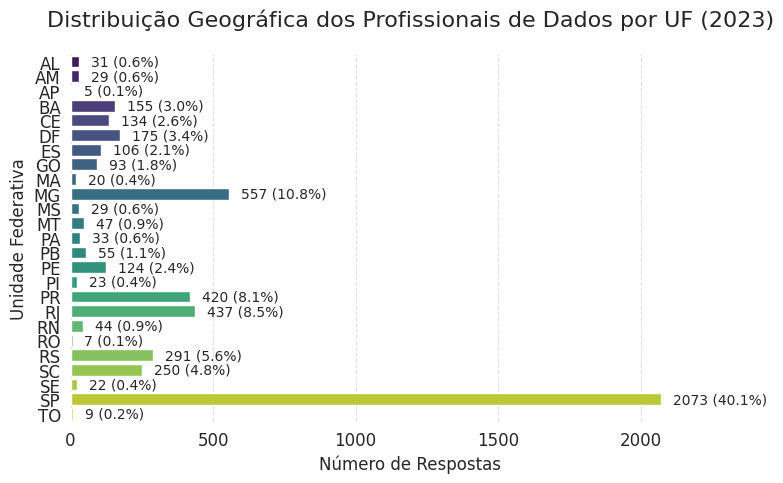

In [ ]:
#Plotagem do grafico Distribuição Geográfica dos Profissionais de Dados por UF (2023)
# Configurações do gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Ordenar por quantidade (opcional - descomente se quiser ordenar por frequência)
# ordem_uf = merged_df['Uf'].value_counts().index
# Ou manter ordem alfabética:
ordem_uf = sorted(merged_df['Uf'].dropna().unique())

# Filtrar NaN
dados_filtrados = merged_df['Uf'].dropna()

# Criar gráfico de barras horizontais
ax = sns.countplot(
    y='Uf',
    data=merged_df,
    order=ordem_uf,
    palette='viridis',  # Paleta de cores sequencial
    orient='h'
)

# Calcular totais e percentuais
total_validos = len(dados_filtrados)
contagens = dados_filtrados.value_counts().reindex(ordem_uf)
percentuais = (contagens / total_validos * 100).round(1)

# Adicionar rótulos
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(
        width + 0.02 * contagens.max(),
        p.get_y() + p.get_height()/2,
        f'{int(width)} ({percentuais[i]}%)',
        va='center',
        ha='left',
        fontsize=10
    )

# Customização
plt.title('Distribuição Geográfica dos Profissionais de Dados por UF (2023)', fontsize=16, pad=20)
plt.xlabel('Número de Respostas', fontsize=12)
plt.ylabel('Unidade Federativa', fontsize=12)
plt.xlim(right=contagens.max() * 1.15)

# Melhorias visuais
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<ipython-input-22-62d04693a728>:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
<ipython-input-22-62d04693a728>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


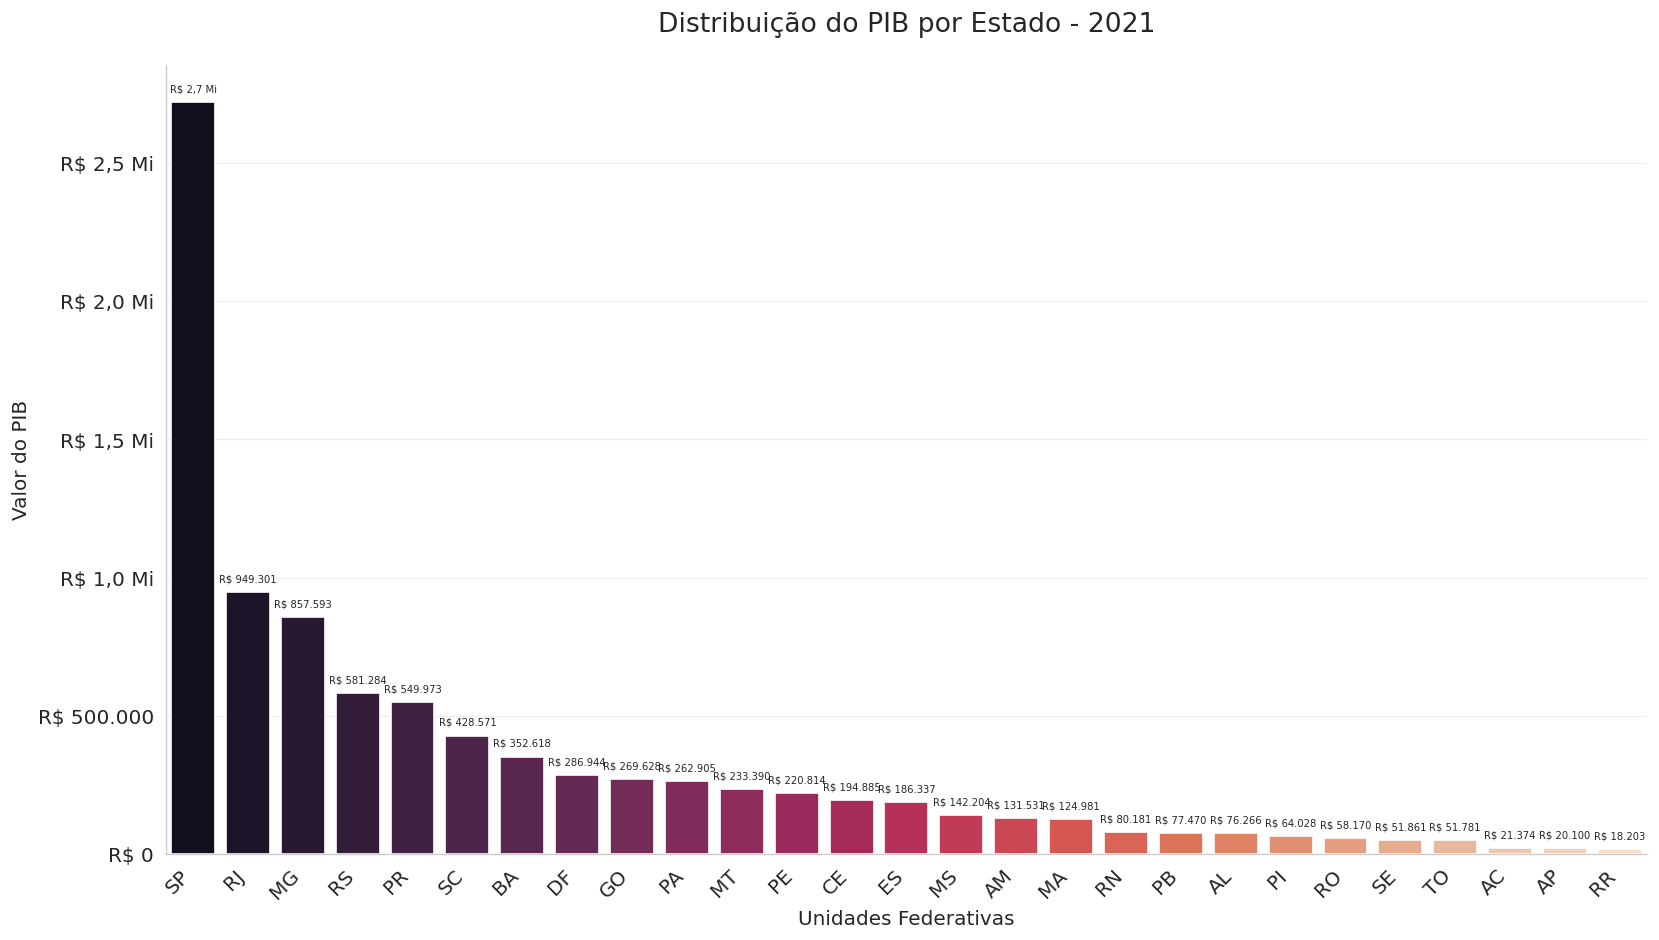

In [ ]:
#Plotagem do grafico Distribuição do PIB por Estado - 2021
# Configurações iniciais CORRIGIDAS
sns.set_style("whitegrid")  # Estilo do Seaborn
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

# 1. Pré-processamento dos dados
# Verificar e converter tipos de dados
pib['PIB_2021_OR'] = pd.to_numeric(pib['PIB_2021_OR'], errors='coerce')
pib['Uf'] = pib['Uf'].str.upper().str.strip()

# Filtrar dados válidos e ordenar
df_pib = pib.dropna(subset=['PIB_2021_OR', 'Uf'])\
           .sort_values('PIB_2021_OR', ascending=False)

# 2. Criar figura
plt.figure(figsize=(14, 8))

# 3. Plotar gráfico de barras
ax = sns.barplot(
    data=df_pib,
    x='Uf',
    y='PIB_2021_OR',
    order=df_pib['Uf'],
    palette='rocket',  # Paleta de cores do Seaborn
    estimator=sum,     # Garante a soma se houver duplicatas
    ci=None
)

# 4. Formatação do eixo Y (em bilhões)
def format_currency(value, _):
    """Formata valores em R$ brasileiro"""
    if value >= 1e9:
        return f'R$ {value/1e9:,.1f} Bi'.replace(',', 'X').replace('.', ',').replace('X', '.')
    elif value >= 1e6:
        return f'R$ {value/1e6:,.1f} Mi'.replace(',', 'X').replace('.', ',').replace('X', '.')
    else:
        return f'R$ {value:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

ax.yaxis.set_major_formatter(plt.FuncFormatter(format_currency))

# 5. Personalização do gráfico
plt.title('Distribuição do PIB por Estado - 2021', fontsize=16, pad=20)
plt.xlabel('Unidades Federativas', fontsize=12)
plt.ylabel('Valor do PIB', fontsize=12)
plt.xticks(rotation=45, ha='right')

# 6. Adicionar valores nas barras
for p in ax.patches:
    value = p.get_height()
    formatted_value = format_currency(value, None)

    ax.annotate(
        formatted_value,
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=6
    )

# 7. Ajustes finais
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [ ]:
#Verificação de valores unicos para plotar grafico
valores_unicos = merged_df['Nível'].unique()
print(valores_unicos)

['Sênior' 'Pleno' 'Júnior' nan]


<ipython-input-24-66e212587f1f>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-24-66e212587f1f>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(largura)} ({percentuais[i]}%)',


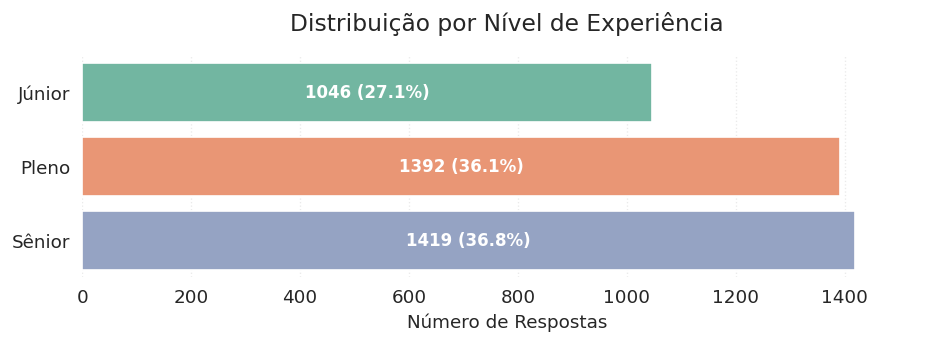

In [ ]:
#Plotagem do grafico Distribuição por Nível de Experiência
# Configurações do gráfico
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# Ordem crescente e cores personalizadas
ordem_niveis = ['Júnior', 'Pleno', 'Sênior']
cores = ['#66c2a5', '#fc8d62', '#8da0cb']  # Verde, Laranja, Roxo (paleta "Set2")

# Filtrar dados
dados_filtrados = merged_df['Nível'].dropna()
dados_filtrados = dados_filtrados[dados_filtrados.isin(ordem_niveis)]

# Criar gráfico
ax = sns.countplot(
    y='Nível',
    data=merged_df,
    order=ordem_niveis,
    palette=cores,  # Usando nossa paleta personalizada
    orient='h'
)

# Cálculos
total_validos = len(dados_filtrados)
contagens = dados_filtrados.value_counts().reindex(ordem_niveis)
percentuais = (contagens / total_validos * 100).round(1)

# Adicionar rótulos
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    ax.text(
        largura / 2,
        p.get_y() + p.get_height()/2,
        f'{int(largura)} ({percentuais[i]}%)',
        va='center',
        ha='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Ajustes finais
plt.title('Distribuição por Nível de Experiência', fontsize=14, pad=15)
plt.xlabel('Número de Respostas', fontsize=11)
plt.ylabel('')
plt.xlim(right=contagens.max() * 1.1)

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

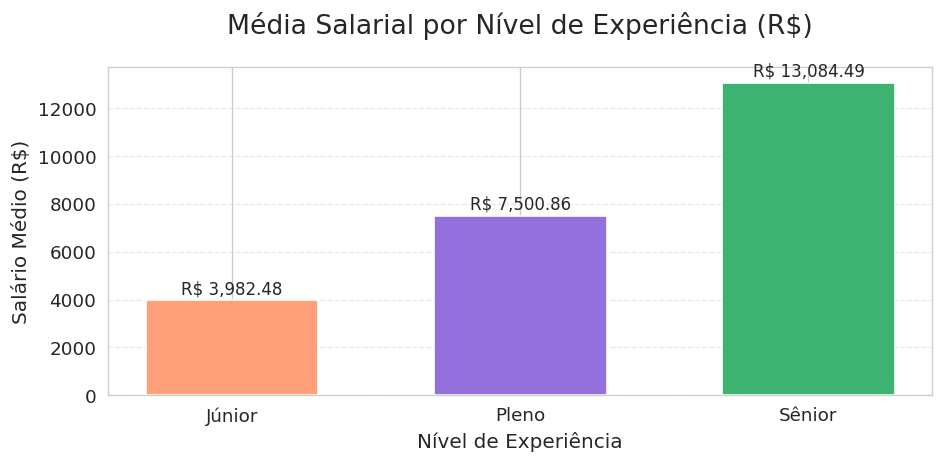

In [ ]:
#Plotagem do grafico  Média Salarial por Nível de Experiência (R$)
# Supondo que seus dados estão em um DataFrame chamado 'dados'
# Calculando as médias salariais por nível
media_por_nivel = merged_df.groupby('Nível')['Salario_Medio'].mean().reindex(['Júnior', 'Pleno', 'Sênior'])

# Configurações do gráfico
cores = {'Júnior': '#FFA07A', 'Pleno': '#9370DB', 'Sênior': '#3CB371'}
niveis = media_por_nivel.index
x = range(len(niveis))

# Criando o gráfico de colunas
plt.figure(figsize=(8, 4))

barras = plt.bar(x, media_por_nivel.values, color=[cores[nivel] for nivel in niveis], width=0.6)

# Personalização
plt.title('Média Salarial por Nível de Experiência (R$)', fontsize=16, pad=20)
plt.xlabel('Nível de Experiência', fontsize=12)
plt.ylabel('Salário Médio (R$)', fontsize=12)
plt.xticks(x, niveis)

# Adicionando valores nas barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 100,
             f'R$ {altura:,.2f}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Verificação de valores unicos para plotar grafico
valores_unicos = merged_df['Tempo_de_experiencia_na_area_de_dados'].unique()
print(valores_unicos)

['de 3 a 4 anos' 'de 1 a 2 anos' nan 'Menos de 1 ano' 'de 7 a 10 anos'
 'Mais de 10 anos' 'de 4 a 6 anos' 'de 5 a 6 anos'
 'Não tenho experiência na área de dados']


<ipython-input-27-43c06b3cbe4f>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-27-43c06b3cbe4f>:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(largura)} ({percentuais[i]}%)',


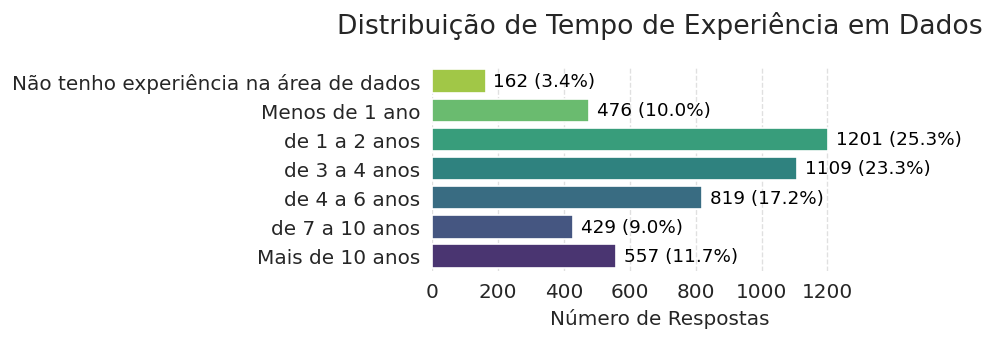

In [ ]:
#Plotagem do grafico Distribuição de Tempo de Experiência em Dados
# Configurações do gráfico
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Ordem CRESCENTE das faixas de experiência (lógica temporal)
ordem_experiencia = [
    'Não tenho experiência na área de dados',
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 4 a 6 anos',      # Agrupa 'de 5 a 6 anos' (consistência)
    'de 7 a 10 anos',
    'Mais de 10 anos'
]

# Unificar categorias similares (opcional)
merged_df['Tempo_de_experiencia_agrupado'] = merged_df['Tempo_de_experiencia_na_area_de_dados'].replace(
    {'de 5 a 6 anos': 'de 4 a 6 anos'}
)

# Filtrar NaN e manter apenas as categorias definidas
dados_filtrados = merged_df['Tempo_de_experiencia_agrupado'].dropna()
dados_filtrados = dados_filtrados[dados_filtrados.isin(ordem_experiencia)]

# Criar o gráfico de barras horizontais (ordem crescente)
ax = sns.countplot(
    y='Tempo_de_experiencia_agrupado',
    data=merged_df,
    order=ordem_experiencia,  # Ordem definida acima
    palette='viridis_r',      # Paleta reversa (cores mais escuras = mais experiência)
    orient='h'
)

# Calcular totais e percentuais
total_validos = len(dados_filtrados)
contagens = dados_filtrados.value_counts().reindex(ordem_experiencia)
percentuais = (contagens / total_validos * 100).round(1)

# Adicionar rótulos com contagem e percentual
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    ax.text(
        largura + 0.02 * contagens.max(),  # Margem de 2% do valor máximo
        p.get_y() + p.get_height()/2,
        f'{int(largura)} ({percentuais[i]}%)',
        va='center',
        ha='left',
        fontsize=11,
        color='black'  # Cor do texto para melhor contraste
    )

# Customização do gráfico
plt.title('Distribuição de Tempo de Experiência em Dados', fontsize=16, pad=20)
plt.xlabel('Número de Respostas', fontsize=12)
plt.ylabel('')
plt.xlim(right=contagens.max() * 1.15)

# Remover bordas e melhorar grid
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
merged_df.head()

,Idade,Faixa de idade,Genero,Cor/Raça/Etnia,PDC,Estado_onde_mora,Uf,Regiao_onde_mora,Mudou_de_estado,Regiao_de_Origem,Nivel_de_Ensino,Area_de_Formacao,Situacao_atual_de_trabalho,Setor,Num_func_empresa_que_trabalha,Cargo_Atual,Nível,Faixa_Salarial,Salario_Minimo,Salario_Maximo,Salario_Medio,Tempo_de_experiencia_na_area_de_dados,Atual_forma_de_trabalho,Papeis/cargos_do_time/chapter_de_dados,Analytics_Engineer,Engenharia_de_Dados/Data_Engineer,Analista_de_Dados/Data_Analyst,Cientista_de_Dados/Data_Scientist,Database_Administrator/DBA,Analista_de_Business_Intelligence/BI,Arquiteto_de_Dados/Data_Architect,Data_Product_Manager/DPM,Business_Analyst,SQL,R,Python,C/C++/C#,NET,Java,Julia,SAS/Stata,Visual Basic/VBA,Scala,Matlab,Rust,PHP,JavaScript,Não utilizo nenhuma linguagem,Azure (Microsoft),Amazon Web Services (AWS),Google Cloud (GCP),Oracle Cloud,IBM,Servidores On Premise/Não utilizamos Cloud,Cloud Própria,Microsoft PowerBI,Qlik View/Qlik Sense,Tableau,Metabase,Superset,Redash,Looker,Looker Studio(Google Data Studio),Amazon Quicksight,Mode,Alteryx,MicroStrategy,IBM Analytics/Cognos,SAP Business Objects/SAP Analytics,Oracle Business Intelligence,Salesforce/Einstein Analytics,Birst,SAS Visual Analytics,Grafana,TIBCO Spotfire,Pentaho,Fazemos todas as análises utilizando apenas Excel ou planilhas do google,Não utilizo nenhuma ferramenta de BI no trabalho,Ano,Nome_Estado,IDHM,IDHM_L,IDHM_E,IDHM_R,IDHMAD,IDHMAD_L,IDHMAD_E,IDHMAD_R,RDPC,GINI,THEIL,PIB_2021_OR,Partic_Pib_Brasil,Num_func_empresa_agrupado,Tempo_de_experiencia_agrupado
0,31,30-34,Masculino,Branca,Não,Minas Gerais (MG),MG,Sudeste,1.0,NaN,Doutorado ou Phd,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Finanças ou Bancos,Acima de 3.000,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,12001.0,16000.0,14000.5,de 3 a 4 anos,Modelo híbrido flexível (o funcionário tem lib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2021.0,Minas Gerais,0.774,0.846,0.762,0.718,0.625,0.777,0.656,0.478,699.24,0.487,0.423,857593.0,0.095,Acima de 3.000,de 3 a 4 anos
1,30,30-34,Masculino,Branca,Não,Espírito Santo (ES),ES,Sudeste,1.0,NaN,Graduação/Bacharelado,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Finanças ou Bancos,de 101 a 500,Analista de BI/BI Analyst,Pleno,de R$ 6.001/mês a R$ 8.000/mês,6001.0,8000.0,7000.5,de 3 a 4 anos,Modelo 100% remoto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021.0,Espírito Santo,0.771,0.864,0.742,0.715,0.611,0.798,0.634,0.450,684.63,0.508,0.452,186337.0,0.021,de 101 a 500,de 3 a 4 anos
2,37,35-39,Feminino,Amarela,Não,São Paulo (SP),SP,Sudeste,1.0,NaN,Graduação/Bacharelado,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Finanças ou Bancos,Acima de 3.000,Analista de Dados/Data Analyst,Júnior,de R$ 6.001/mês a R$ 8.000/mês,6001.0,8000.0,7000.5,de 1 a 2 anos,Modelo híbrido flexível (o funcionário tem lib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2021.0,São Paulo,0.806,0.810,0.839,0.771,0.654,0.744,0.752,0.500,971.82,0.533,0.495,2719751.0,0.302,Acima de 3.000,de 1 a 2 anos
3,22,22-24,Masculino,Preta,Não,São Paulo (SP),SP,Sudeste,1.0,NaN,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,"Desempregado, buscando recolocação",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
merged_df.select_dtypes(include=['int64', 'float64']).describe()

,Idade,Mudou_de_estado,Salario_Minimo,Salario_Maximo,Salario_Medio,Analytics_Engineer,Engenharia_de_Dados/Data_Engineer,Analista_de_Dados/Data_Analyst,Cientista_de_Dados/Data_Scientist,Database_Administrator/DBA,Analista_de_Business_Intelligence/BI,Arquiteto_de_Dados/Data_Architect,Data_Product_Manager/DPM,Business_Analyst,SQL,R,Python,C/C++/C#,NET,Java,Julia,SAS/Stata,Visual Basic/VBA,Scala,Matlab,Rust,PHP,JavaScript,Não utilizo nenhuma linguagem,Azure (Microsoft),Amazon Web Services (AWS),Google Cloud (GCP),Oracle Cloud,IBM,Servidores On Premise/Não utilizamos Cloud,Cloud Própria,Microsoft PowerBI,Qlik View/Qlik Sense,Tableau,Metabase,Superset,Redash,Looker,Looker Studio(Google Data Studio),Amazon Quicksight,Mode,Alteryx,MicroStrategy,IBM Analytics/Cognos,SAP Business Objects/SAP Analytics,Oracle Business Intelligence,Salesforce/Einstein Analytics,Birst,SAS Visual Analytics,Grafana,TIBCO Spotfire,Pentaho,Fazemos todas as análises utilizando apenas Excel ou planilhas do google,Não utilizo nenhuma ferramenta de BI no trabalho,Ano,IDHM,IDHM_L,IDHM_E,IDHM_R,IDHMAD,IDHMAD_L,IDHMAD_E,IDHMAD_R,RDPC,GINI,THEIL,PIB_2021_OR,Partic_Pib_Brasil
count,5293.000000,5172.000000,4753.000000,4651.000000,4651.000000,859.000000,859.000000,859.000000,859.000000,859.000000,859.000000,859.000000,859.000000,859.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,5169.0,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000,5.169000e+03,5169.000000
mean,31.997166,0.794277,8941.683779,11545.259084,10028.676736,0.322468,0.654249,0.675204,0.623981,0.222352,0.547148,0.324796,0.240978,0.395809,0.836691,0.108165,0.748940,0.018558,0.010604,0.094115,0.002121,0.040032,0.075557,0.034730,0.007953,0.001856,0.014846,0.074761,0.080859,0.423194,0.306117,0.315804,0.042624,0.013009,0.161085,0.069471,0.571050,0.051432,0.189024,0.085896,0.022534,0.016437,0.238070,0.173118,0.036585,0.003446,0.026511,0.009809,0.006628,0.021209,0.012990,0.022534,0.001326,0.022534,0.073171,0.007158,0.046660,0.103659,0.108431,2021.0,0.777362,0.802012,0.788344,0.744163,0.622711,0.731335,0.689492,0.480469,848.458450,0.518235,0.473260,1.409338e+06,0.156507
std,7.623498,0.404268,7301.151364,7714.658899,6969.224358,0.467693,0.475890,0.468572,0.484667,0.416068,0.498062,0.468572,0.427926,0.489309,0.369696,0.310630,0.433681,0.134975,0.102444,0.292027,0.046010,0.196060,0.264323,0.183118,0.088838,0.043044,0.120953,0.263041,0.272655,0.494134,0.460943,0.464900,0.202036,0.113327,0.367660,0.254289,0.494992,0.220906,0.391580,0.280248,0.148433,0.127165,0.425959,0.378399,0.187766,0.058613,0.160671,0.098567,0.081152,0.144099,0.113248,0.148433,0.036389,0.148433,0.260451,0.084313,0.210937,0.304857,0.310965,0.0,0.034069,0.028489,0.050448,0.042863,0.044549,0.034298,0.068773,0.047890,196.345133,0.038437,0.074035,1.095699e+06,0.121622
min,18.000000,0.000000,101.000000,2000.000000,1050.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2021.0,0.676000,0.715000,0.647000,0.603000,0.493000,0.619000,0.502000,0.354000,341.320

In [ ]:
idh.describe()

,Ano,IDHM,IDHM_L,IDHM_E,IDHM_R,IDHMAD,IDHMAD_L,IDHMAD_E,IDHMAD_R,RDPC,GINI,THEIL
count,27.0,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,2021.0,0.730148,0.774667,0.727074,0.692333,0.564074,0.690630,0.604259,0.432333,629.156667,0.522889,0.490370
std,0.0,0.039892,0.038299,0.049759,0.053364,0.053156,0.047806,0.070458,0.061555,229.435247,0.044058,0.087397
min,2021.0,0.676000,0.715000,0.647000,0.603000,0.493000,0.619000,0.502000,0.354000,341.320000,0.424000,0.302000
25%,2021.0,0.698500,0.744500,0.685000,0.648500,0.521500,0.654000,0.550500,0.381000,452.170000,0.491500,0.426000
50%,2021.0,0.728000,0.778000,0.721000,0.680000,0.543000,0.689000,0.580000,0.395000,549.540000,0.529000,0.499000
75%,2021.0,0.765500,0.797000,0.760000,0.726500,0.603000,0.724500,0.657000,0.487000,737.580000,0.555500,0.553500
max,2021.0,0.814000,0.864000,0.839000,0.821000,0.670000,0.798000,0.752000,0.565000,1326.870000,0.596000,0.639000


In [ ]:
pib.head()

,Uf,PIB_2021_OR,Partic_Pib_Brasil
0,RO,58170,0.006
1,AC,21374,0.002
2,AM,131531,0.015
3,RR,18203,0.002
4,PA,262905,0.029


In [ ]:
#Verificação de valores unicos para plotagem do grafico
valores_unicos = merged_df['Cor/Raça/Etnia'].unique()
print(valores_unicos)

['Branca' 'Amarela' 'Preta' 'Parda' 'Prefiro não informar' 'Outra'
 'Indígena']


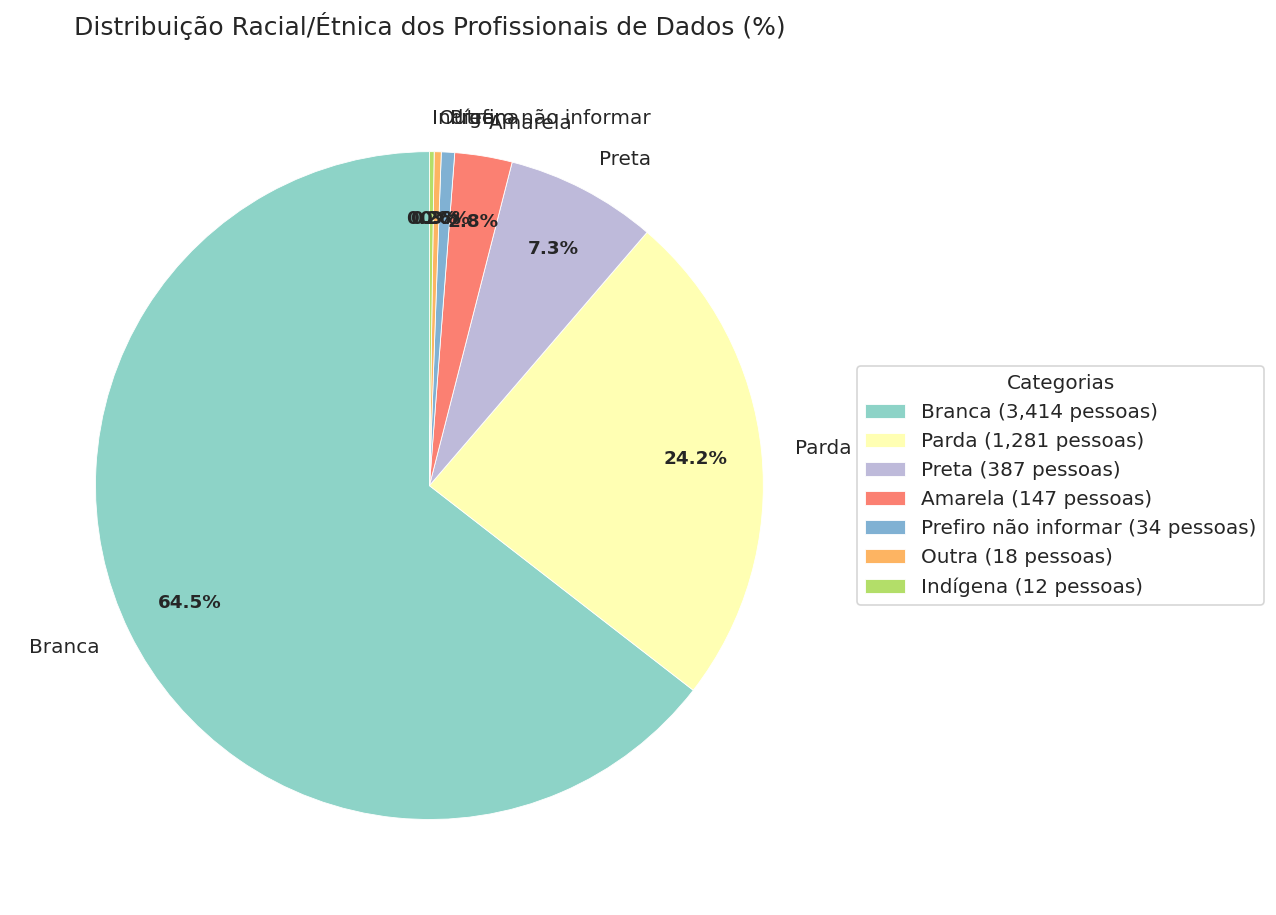

In [ ]:
#Plotagem do grafico Distribuição Racial/Étnica dos Profissionais de Dados (%)
# Calcular porcentagens
contagem = merged_df['Cor/Raça/Etnia'].value_counts()
porcentagens = contagem/contagem.sum()*100

# Plotar
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    porcentagens,
    labels=porcentagens.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set3'),
    pctdistance=0.8,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

# Melhorar a legibilidade
plt.setp(autotexts, size=11, weight="bold")
plt.setp(texts, size=12)

# Adicionar título e legenda
plt.title('Distribuição Racial/Étnica dos Profissionais de Dados (%)', fontsize=15, pad=20)
plt.legend(
    title="Categorias",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    labels=[f'{l} ({s:,.0f} pessoas)' for l, s in zip(porcentagens.index, contagem)]
)

plt.tight_layout()
plt.show()

In [ ]:
#Verificação de valores unicos para plotar grafico
valores_unicos = merged_df['Nivel_de_Ensino'].unique()
print(valores_unicos)

['Doutorado ou Phd' 'Graduação/Bacharelado' 'Estudante de Graduação'
 'Pós-graduação' 'Mestrado' 'Não tenho graduação formal'
 'Prefiro não informar']


<ipython-input-35-a16f76c619ce>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-35-a16f76c619ce>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(largura)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"


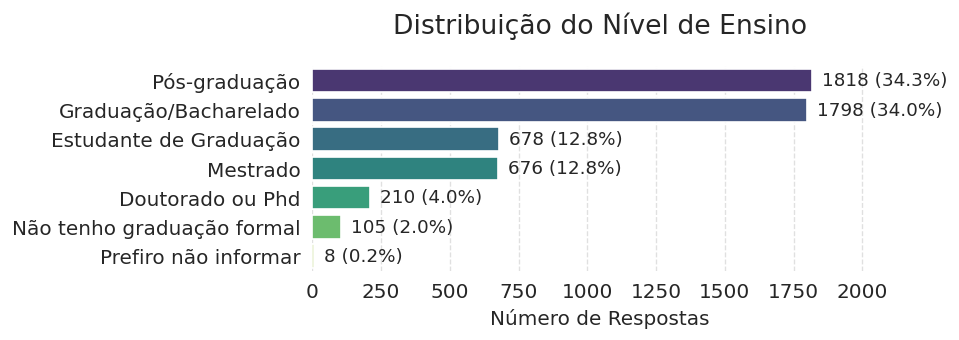

In [ ]:
#Plotagem do grafico Distribuição do Nível de Ensino
# Configurações do gráfico
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Ordem desejada para as categorias (ajuste conforme necessário)
ordem_nivel = [
    'Pós-graduação',
    'Graduação/Bacharelado',
    'Estudante de Graduação',
    'Mestrado',
    'Doutorado ou Phd',
    'Não tenho graduação formal',
    'Prefiro não informar'
]

# Filtrar apenas categorias existentes e remover NaN
dados_filtrados = merged_df['Nivel_de_Ensino'].dropna()
categorias_existentes = [nivel for nivel in ordem_nivel if nivel in dados_filtrados.unique()]

# Criar o gráfico de barras
ax = sns.countplot(
    y='Nivel_de_Ensino',
    data=merged_df,
    order=categorias_existentes,
    palette='viridis',
    orient='h'
)

# Calcular totais e percentuais (ignorando NaN)
total_respostas = len(dados_filtrados)
contagens = dados_filtrados.value_counts().reindex(categorias_existentes)
percentuais = (contagens / total_respostas * 100).round(1)

# Adicionar os valores e percentuais nas barras
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    ax.text(
        largura + 0.02 * contagens.max(),  # Posição do texto (2% do valor máximo como margem)
        p.get_y() + p.get_height()/2,
        f'{int(largura)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"
        va='center',
        ha='left',
        fontsize=11
    )

# Ajustes estéticos
plt.title('Distribuição do Nível de Ensino', fontsize=16, pad=20)
plt.xlabel('Número de Respostas', fontsize=12)
plt.ylabel('')
plt.xlim(right=contagens.max() * 1.15)  # Ajuste para caber os textos

# Remover bordas e adicionar grid
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

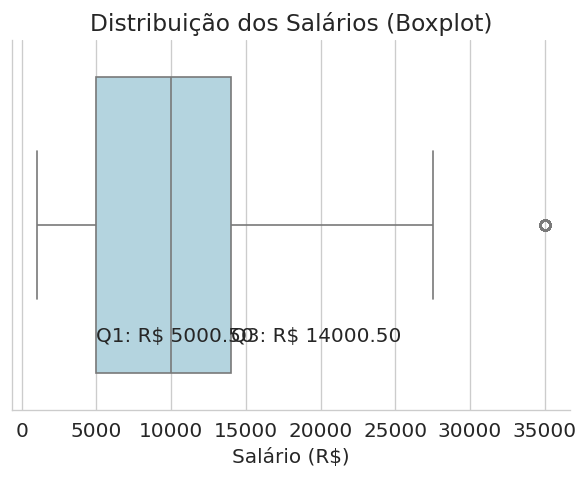

In [ ]:
#Plotagem do grafico Distribuição dos Salários (Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=merged_df['Salario_Medio'].dropna(), color='lightblue', orient='h')

# Adicionar estatísticas
stats = merged_df['Salario_Medio'].describe()
plt.text(stats['75%'], 0.3, f"Q3: R$ {stats['75%']:.2f}", va='center')
plt.text(stats['25%'], 0.3, f"Q1: R$ {stats['25%']:.2f}", va='center')

plt.title('Distribuição dos Salários (Boxplot)', fontsize=14)
plt.xlabel('Salário (R$)', fontsize=12)
sns.despine()

plt.show()

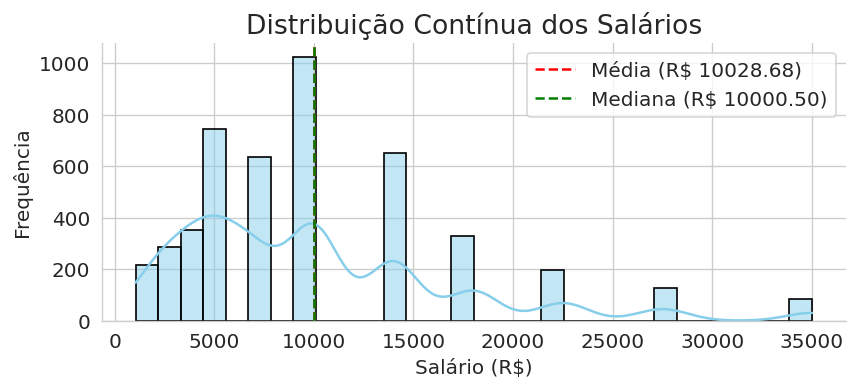

In [ ]:
#Plotagem do grafico Distribuição Contínua dos Salários
# Configurações
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")

# Filtrar NaN e criar histograma
dados_salario = merged_df['Salario_Medio'].dropna()
ax = sns.histplot(dados_salario, bins=30, kde=True, color='skyblue', edgecolor='black')

# Destacar a média/mediana
plt.axvline(dados_salario.mean(), color='red', linestyle='--', label=f'Média (R$ {dados_salario.mean():.2f})')
plt.axvline(dados_salario.median(), color='green', linestyle='--', label=f'Mediana (R$ {dados_salario.median():.2f})')

# Ajustes visuais
plt.title('Distribuição Contínua dos Salários', fontsize=16)
plt.xlabel('Salário (R$)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
sns.despine()

plt.show()

In [ ]:
#Calculando a média salarial agrupada por UF (Unidade Federativa) e Gênero em um DataFrame chamado merged_df
media_salarial = merged_df.groupby(['Uf', 'Genero'])['Salario_Medio'].mean().unstack()

In [ ]:
media_salarial_ordenada = media_salarial.sort_values(by='Feminino', ascending=False)  # Ordem decrescente pela média feminina

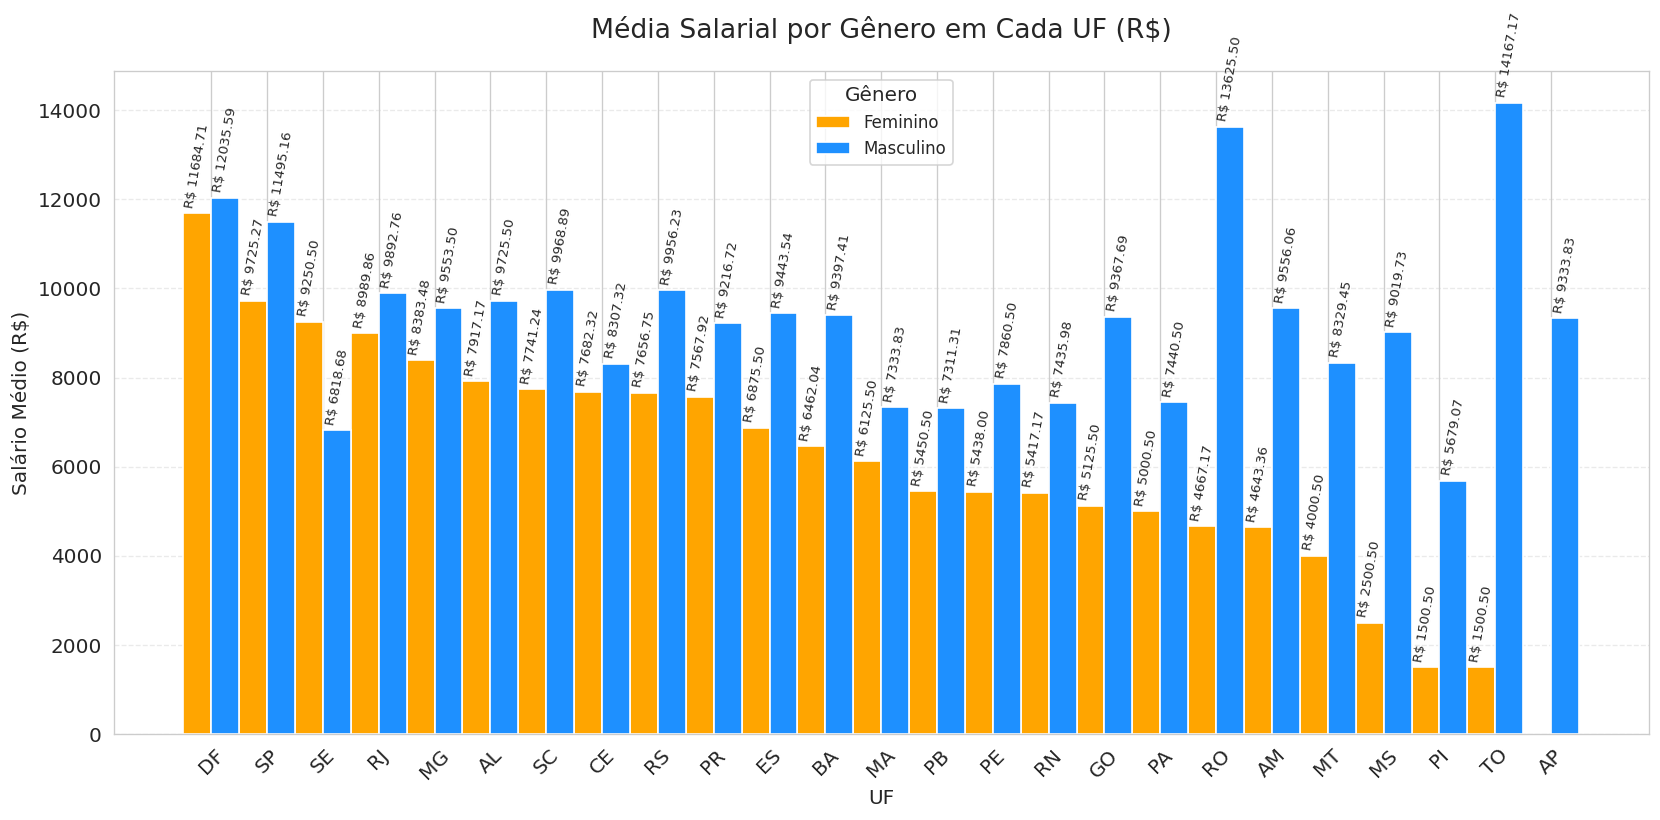

In [ ]:
#Plotagem do grafico Média Salarial por Gênero em Cada UF (R$)
# Configurações
cores = {'Feminino': '#FFA500', 'Masculino': '#1E90FF'}
largura_barras = 0.5
ufs = media_salarial_ordenada.index
x = np.arange(len(ufs))

# Plotar
plt.figure(figsize=(14, 7))
plt.bar(x - largura_barras/2, media_salarial_ordenada['Feminino'], width=largura_barras, color=cores['Feminino'], label='Feminino')
plt.bar(x + largura_barras/2, media_salarial_ordenada['Masculino'], width=largura_barras, color=cores['Masculino'], label='Masculino')

# Personalização
plt.title('Média Salarial por Gênero em Cada UF (R$)', fontsize=16, pad=20)
plt.xlabel('UF', fontsize=12)
plt.ylabel('Salário Médio (R$)', fontsize=12)
plt.xticks(x, ufs, rotation=45)
plt.legend(title='Gênero', fontsize=10)

# Adicionar valores nas barras (opcional)
for i in x:
    plt.text(i - largura_barras/2, media_salarial_ordenada['Feminino'].iloc[i] + 100,
             f'R$ {media_salarial_ordenada["Feminino"].iloc[i]:.2f}', ha='center', va='bottom', fontsize=8, rotation=80)
    plt.text(i + largura_barras/2, media_salarial_ordenada['Masculino'].iloc[i] + 100,
             f'R$ {media_salarial_ordenada["Masculino"].iloc[i]:.2f}', ha='center', va='bottom', fontsize=8, rotation=80)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

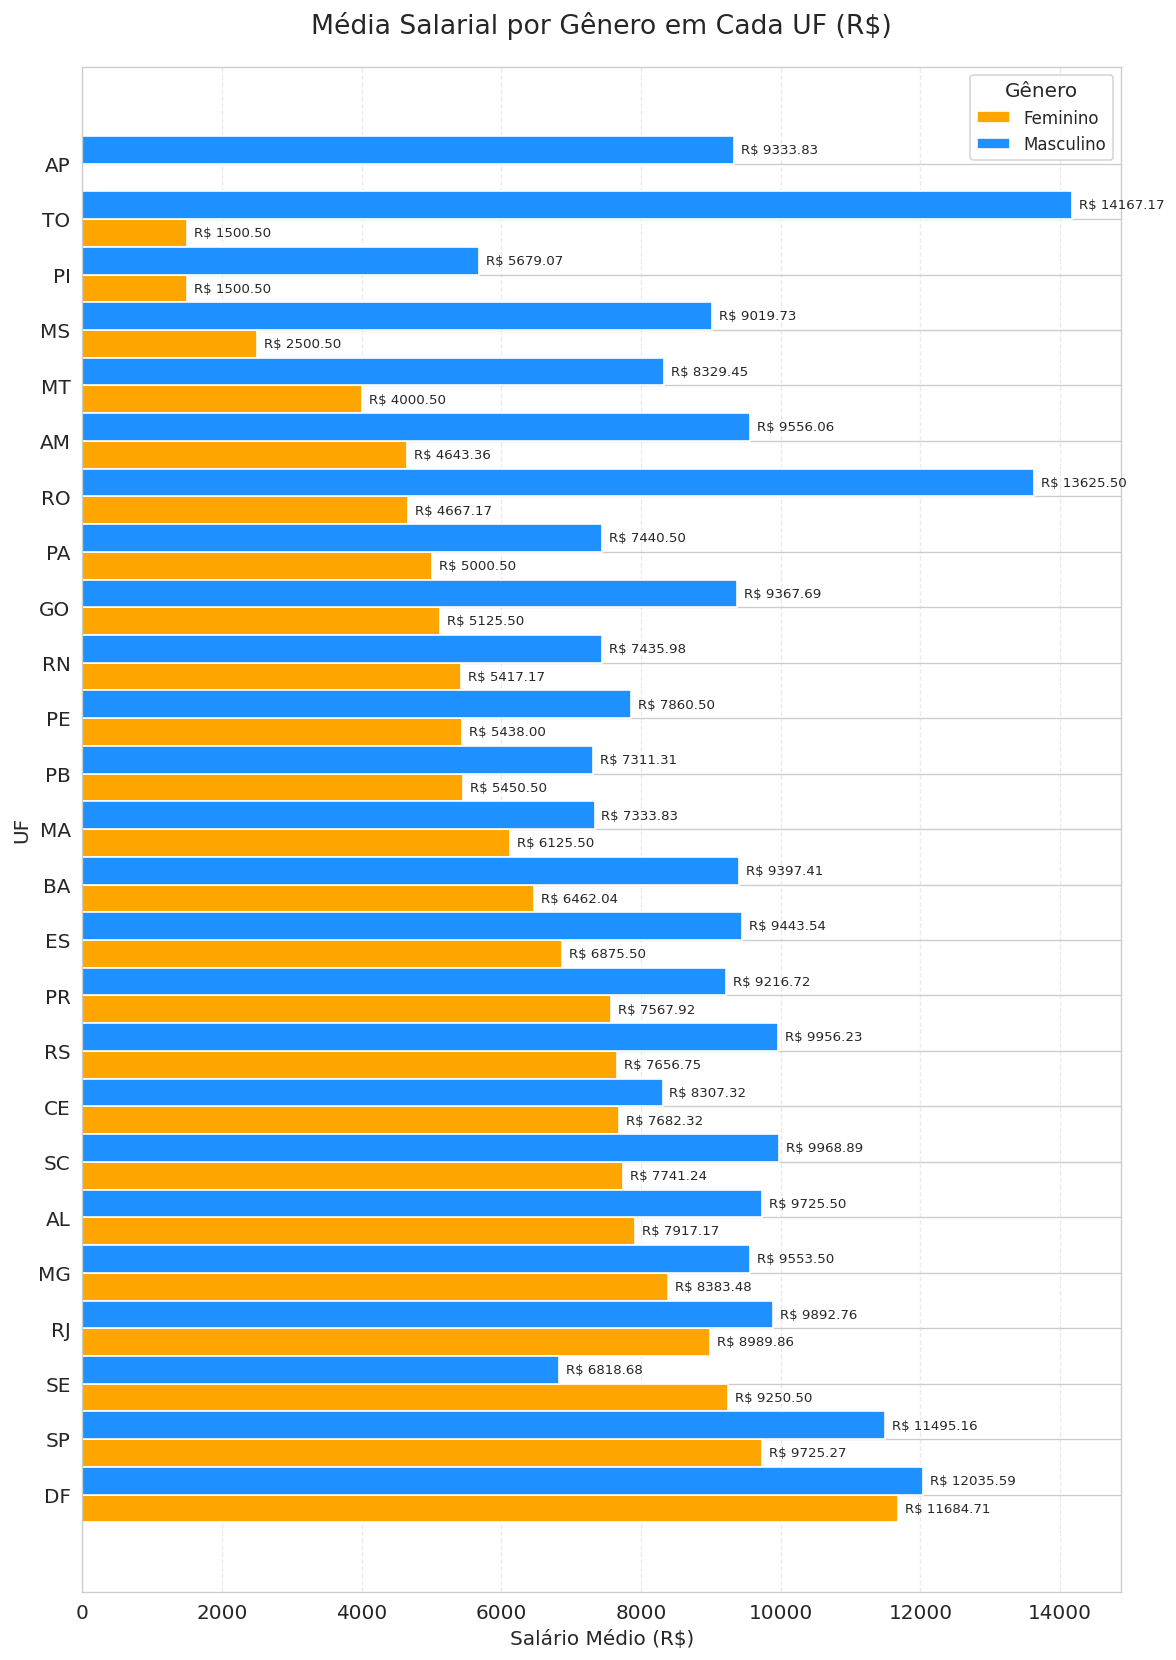

In [ ]:
#Plotagem do grafico Média Salarial por Gênero em Cada UF (R$)
# Configurações
cores = {'Feminino': '#FFA500', 'Masculino': '#1E90FF'}
altura_barras = 0.5  # Alterado de largura_barras para altura_barras
ufs = media_salarial_ordenada.index
y = np.arange(len(ufs))  # Alterado de x para y (eixo vertical)

# Plotar
plt.figure(figsize=(10, 14))  # Inverti as dimensões para melhor visualização
plt.barh(y - altura_barras/2, media_salarial_ordenada['Feminino'], height=altura_barras,
         color=cores['Feminino'], label='Feminino')
plt.barh(y + altura_barras/2, media_salarial_ordenada['Masculino'], height=altura_barras,
         color=cores['Masculino'], label='Masculino')

# Personalização
plt.title('Média Salarial por Gênero em Cada UF (R$)', fontsize=16, pad=20)
plt.xlabel('Salário Médio (R$)', fontsize=12)  # Agora o salário está no eixo x
plt.ylabel('UF', fontsize=12)  # As UFs estão no eixo y
plt.yticks(y, ufs)  # Removi a rotação pois não é mais necessária
plt.legend(title='Gênero', fontsize=10)

# Adicionar valores nas barras (opcional)
for i in y:
    plt.text(media_salarial_ordenada['Feminino'].iloc[i] + 100, i - altura_barras/2,
             f'R$ {media_salarial_ordenada["Feminino"].iloc[i]:.2f}',
             ha='left', va='center', fontsize=8)
    plt.text(media_salarial_ordenada['Masculino'].iloc[i] + 100, i + altura_barras/2,
             f'R$ {media_salarial_ordenada["Masculino"].iloc[i]:.2f}',
             ha='left', va='center', fontsize=8)

plt.grid(axis='x', linestyle='--', alpha=0.4)  # Alterado para grid no eixo x
plt.tight_layout()
plt.show()

In [ ]:
#Verificação de valores unicos para plotar grafico
valores_unicos = merged_df['Cor/Raça/Etnia'].unique()
print(valores_unicos)

['Branca' 'Amarela' 'Preta' 'Parda' 'Prefiro não informar' 'Outra'
 'Indígena']


<ipython-input-43-32e2d5d0ac32>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-43-32e2d5d0ac32>:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{int(width)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"


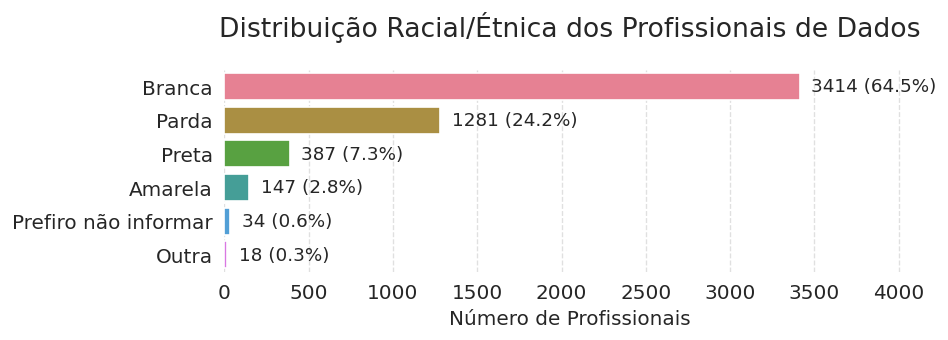

In [ ]:
#Plotagem do grafico 'Distribuição Racial/Étnica dos Profissionais de Dados
# Configurações iniciais
plt.figure(figsize=(8, 3))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Ordem sugerida para as categorias (ajuste conforme seus dados)
ordem_racas = [
    'Branca',
    'Parda',
    'Preta',
    'Amarela',
     'Prefiro não informar',
    'Outra'
]

# Filtrar apenas as categorias existentes no DataFrame
racas_existentes = [r for r in ordem_racas if r in merged_df['Cor/Raça/Etnia'].unique()]

# Criar o gráfico de barras horizontais
ax = sns.countplot(
    data=merged_df,
    y='Cor/Raça/Etnia',
    order=racas_existentes,
    palette='husl',
    orient='h'
)

# Calcular totais e percentuais
total = len(merged_df)
contagens = merged_df['Cor/Raça/Etnia'].value_counts().reindex(racas_existentes)
percentuais = (contagens / total * 100).round(1)

# Adicionar os valores ABSOLUTOS e PERCENTUAIS nas barras
for i, p in enumerate(ax.patches):
    width = p.get_width()
    categoria = racas_existentes[i]
    ax.text(
        width + 0.02 * contagens.max(),  # Margem de 2% do valor máximo
        p.get_y() + p.get_height()/2,
        f'{int(width)} ({percentuais[i]}%)',  # Formato: "N (XX.X%)"
        va='center',
        ha='left',
        fontsize=11
    )

# Customização do gráfico
plt.title('Distribuição Racial/Étnica dos Profissionais de Dados', fontsize=16, pad=20)
plt.xlabel('Número de Profissionais', fontsize=12)
plt.ylabel('')
plt.xlim(right=contagens.max() * 1.2)  # Ajuste para caber os textos

# Adicionar grid e remover bordas
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<ipython-input-44-deffb9f5d9eb>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_por_uf.index, y=media_por_uf.values, palette='viridis')


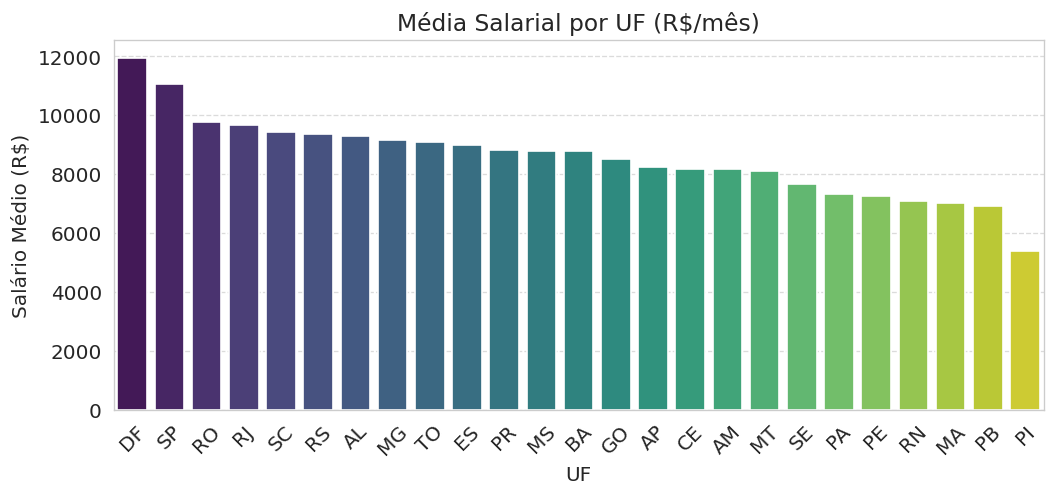

In [ ]:
# Plotagem do grafico Média Salarial por UF (R$/mês)
media_por_uf = merged_df.groupby('Uf')['Salario_Medio'].mean().sort_values(ascending=False)

# Plotar
plt.figure(figsize=(10, 4))
sns.barplot(x=media_por_uf.index, y=media_por_uf.values, palette='viridis')
plt.title('Média Salarial por UF (R$/mês)', fontsize=14)
plt.xlabel('UF')
plt.ylabel('Salário Médio (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<ipython-input-45-7c128c47aba7>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


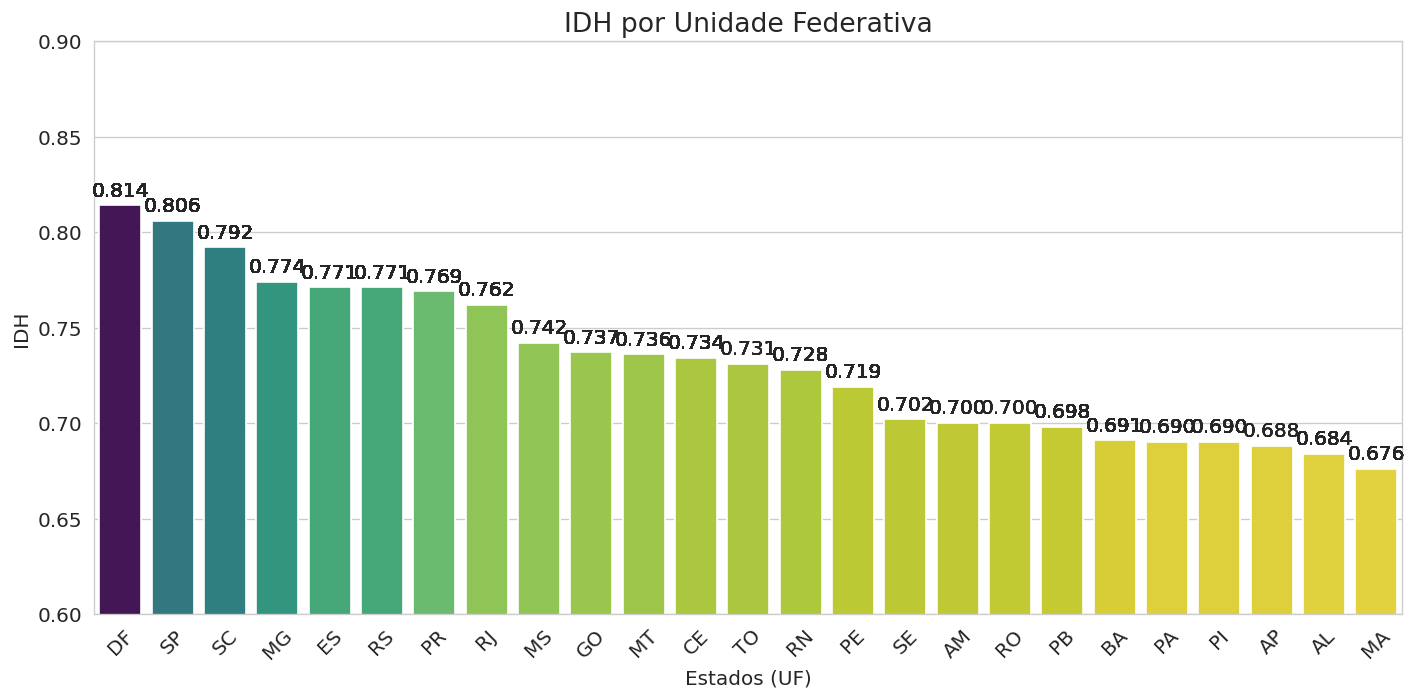

In [ ]:
#Plotagem do grafico IDH por Unidade Federativa
# Filtrar linhas com IDHM ou Uf nulos e ordenar
df_idh = merged_df.dropna(subset=['IDHM', 'Uf']).sort_values('IDHM', ascending=False)

# Plotar
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=df_idh,
    x='Uf',
    y='IDHM',
    palette='viridis',
    order=df_idh['Uf']  # Garante a ordenação
)

# Personalização
plt.title('IDH por Unidade Federativa', fontsize=16)
plt.xlabel('Estados (UF)')
plt.ylabel('IDH')
plt.xticks(rotation=45)
plt.ylim(0.6, 0.9)  # Ajuste conforme seus dados

# Adicionar valores nas barras
for p in barplot.patches:
    barplot.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 9), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

<ipython-input-46-7a211ac3cef9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
<ipython-input-46-7a211ac3cef9>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_yticklabels([f'{x/1e6:.1f}M' for x in barplot.get_yticks()])


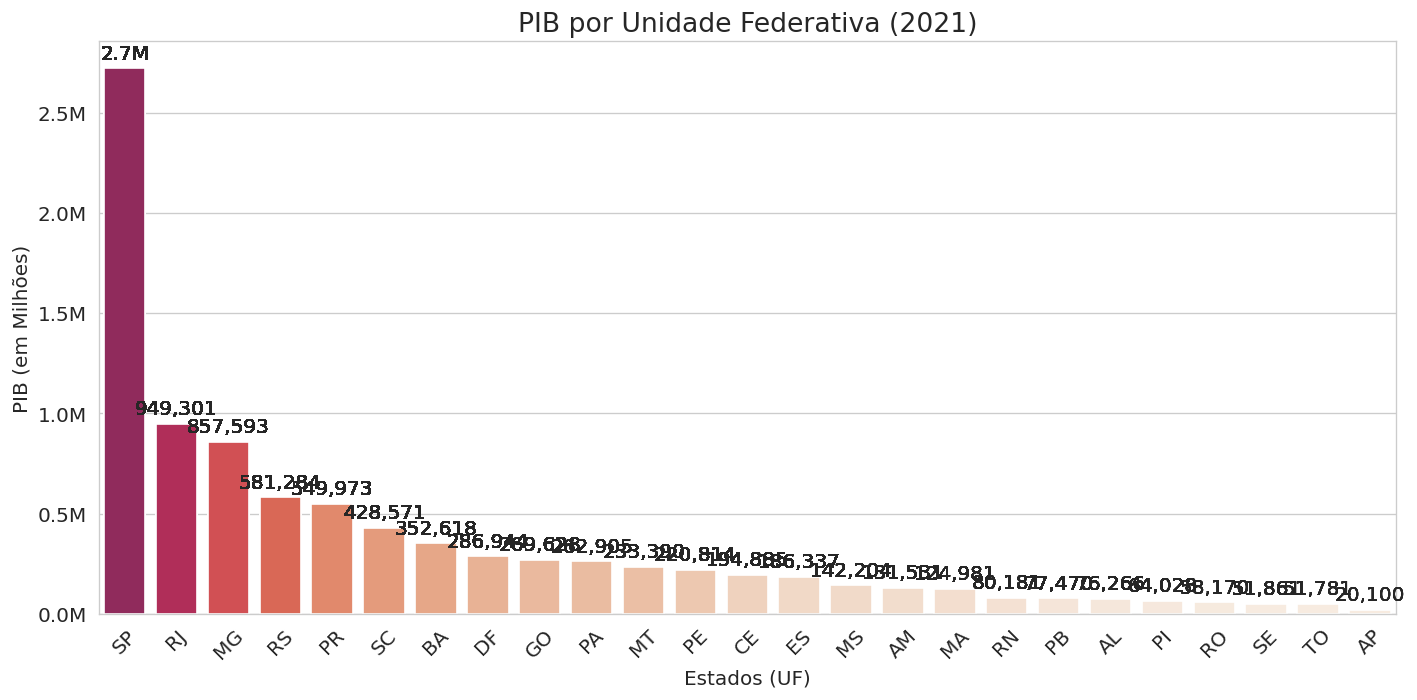

In [ ]:
#Plotagem do gráfico PIB por Unidade Federativa (2021)
# Filtrar linhas com PIB ou Uf nulos e ordenar
df_pib = merged_df.dropna(subset=['PIB_2021_OR', 'Uf']).sort_values('PIB_2021_OR', ascending=False)

# Plotar
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=df_pib,
    x='Uf',
    y='PIB_2021_OR',
    palette='rocket',
    order=df_pib['Uf']  # Garante a ordenação
)

# Personalização
plt.title('PIB por Unidade Federativa (2021)', fontsize=16)
plt.xlabel('Estados (UF)')
plt.ylabel('PIB (Valores Originais)')
plt.xticks(rotation=45)

# Formatar eixo Y automaticamente (milhões/bilhões)
max_pib = df_pib['PIB_2021_OR'].max()
if max_pib > 1e9:
    plt.ylabel('PIB (em Bilhões)')
    barplot.set_yticklabels([f'{x/1e9:.1f}B' for x in barplot.get_yticks()])
elif max_pib > 1e6:
    plt.ylabel('PIB (em Milhões)')
    barplot.set_yticklabels([f'{x/1e6:.1f}M' for x in barplot.get_yticks()])

# Adicionar valores nas barras
for p in barplot.patches:
    value = p.get_height()
    if value > 1e9:
        text = f'{value/1e9:.1f}B'
    elif value > 1e6:
        text = f'{value/1e6:.1f}M'
    else:
        text = f'{value:,.0f}'

    barplot.annotate(
        text,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 9), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

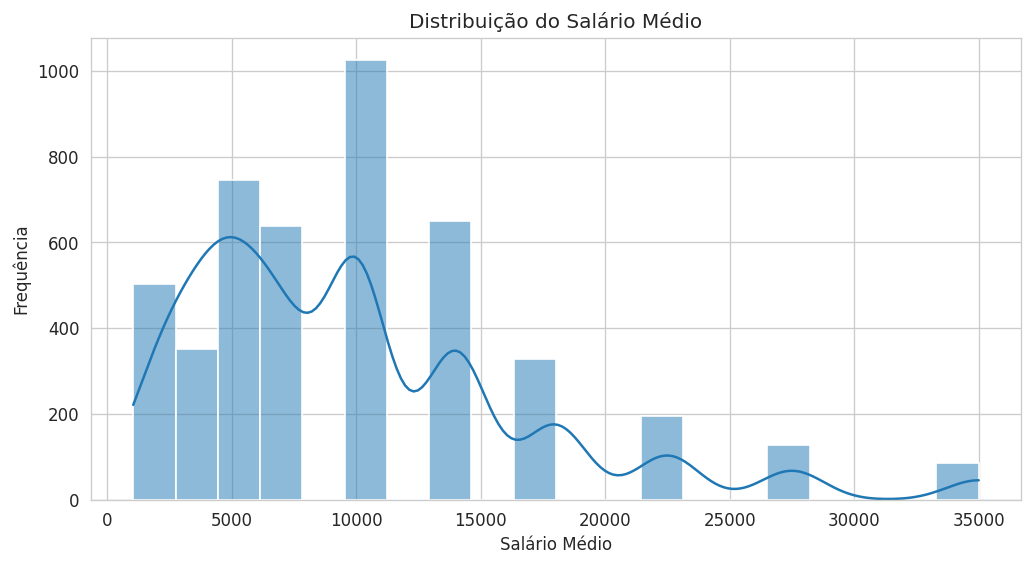

In [ ]:
#Plotagem do gráfico Distribuição do Salário Médio
plt.figure(figsize=(10, 5))
sns.histplot(merged_df['Salario_Medio'], kde=True, bins=20)
plt.title('Distribuição do Salário Médio')
plt.xlabel('Salário Médio')
plt.ylabel('Frequência')
plt.show()

<Figure size 2400x1800 with 0 Axes>

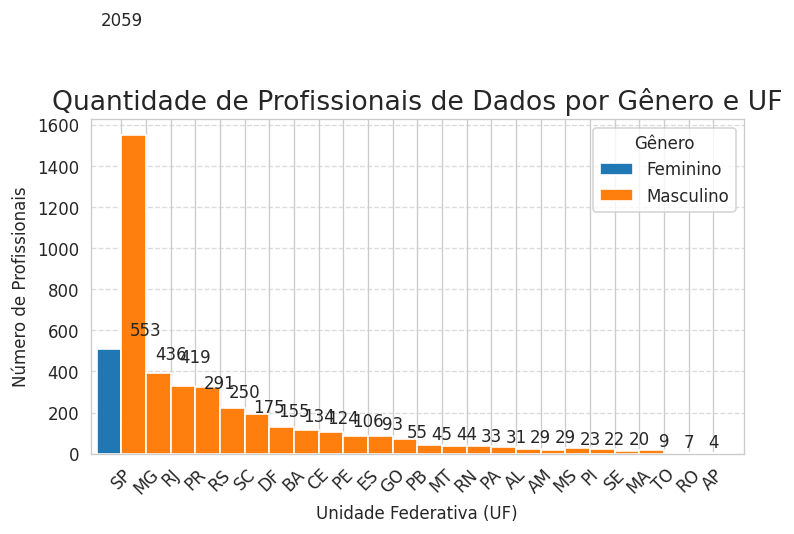

In [ ]:
#Plotagem do gráfico Quantidade de Profissionais de Dados por Gênero e UF
# Filtrar e preparar os dados
df_genero = merged_df.dropna(subset=['Genero', 'Uf'])  # Remove linhas com gênero ou UF nulos
df_genero = df_genero[df_genero['Genero'].isin(['Masculino', 'Feminino'])]  # Mantém apenas M/F

# Contar profissionais por UF e Gênero
contagem = df_genero.groupby(['Uf', 'Genero']).size().unstack().fillna(0)

# Ordenar por total de profissionais (opcional)
contagem = contagem.loc[(contagem['Masculino'] + contagem['Feminino']).sort_values(ascending=False).index]

# Plotar
plt.figure(figsize=(20, 15))
contagem.plot(kind='bar', stacked=False, color=['#1f77b4', '#ff7f0e'], width=2)
plt.title('Quantidade de Profissionais de Dados por Gênero e UF', fontsize=16)
plt.xlabel('Unidade Federativa (UF)')
plt.ylabel('Número de Profissionais')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gênero')

# Adicionar totais acima das barras
for i, uf in enumerate(contagem.index):
    total = contagem.loc[uf].sum()
    plt.text(i, total + 5, f'{total:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

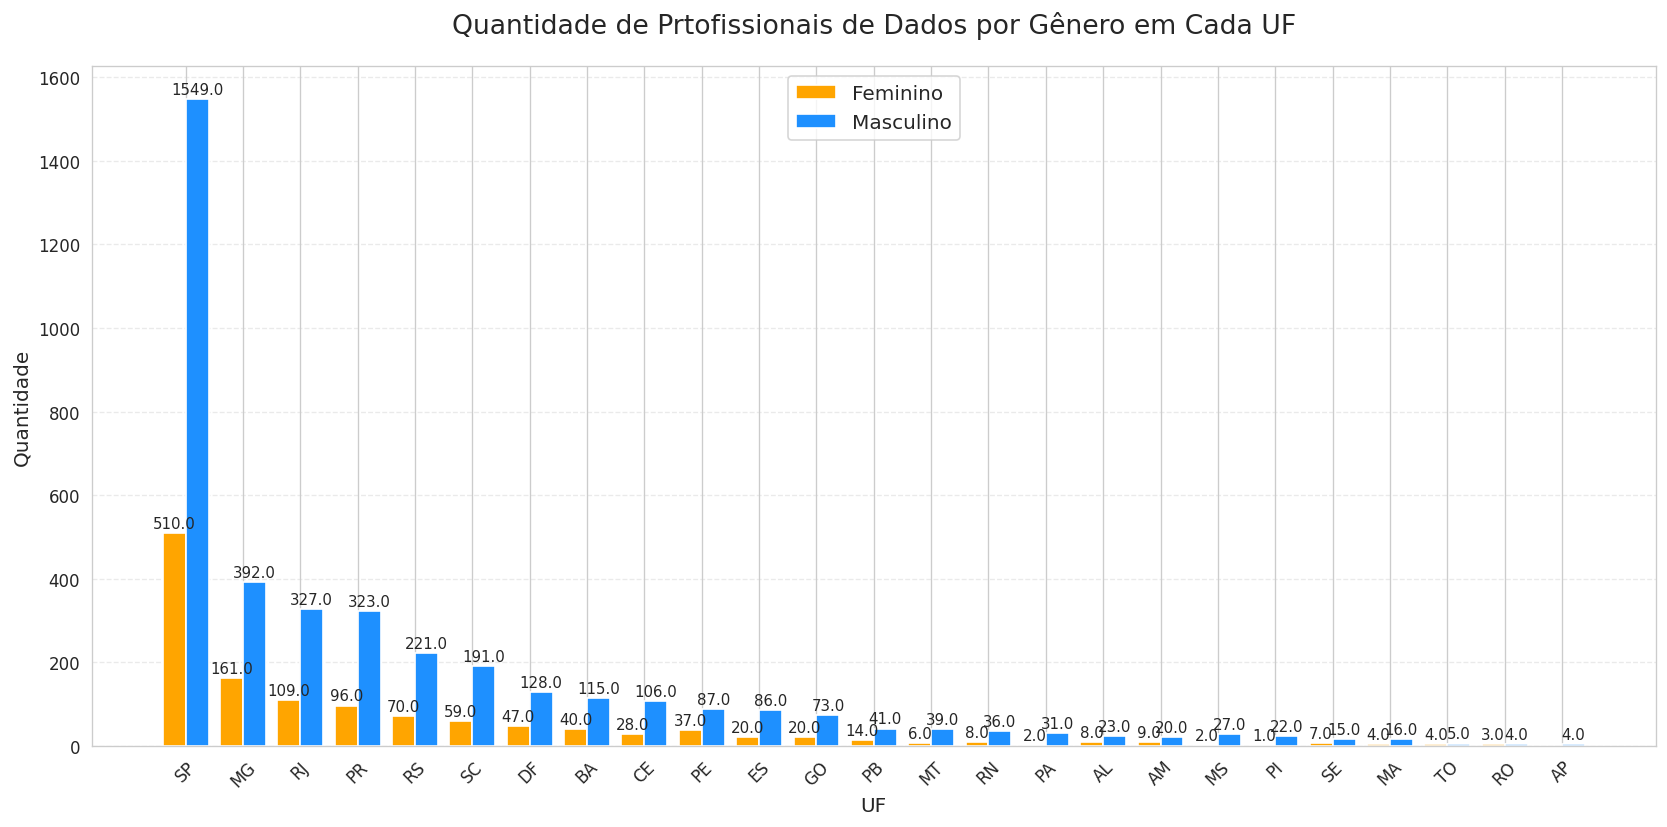

In [ ]:
#Plotagem do gráfico quantidade de Prtofissionais de Dados por Gênero em Cada UF
# 1. Calcular a contagem por UF e Gênero
contagem = merged_df.groupby(['Uf', 'Genero']).size().unstack()

# 2. Ordenar as UFs pela SOMA TOTAL (Feminino + Masculino) em ordem DECRESCENTE
contagem['Total'] = contagem.sum(axis=1)  # Adiciona coluna de total
contagem_ordenada = contagem.sort_values('Total', ascending=False).drop('Total', axis=1)  # Ordena e remove a coluna auxiliar

# 3. Definir cores e largura
cores = {'Feminino': '#FFA500', 'Masculino': '#1E90FF'}
largura_barras = 0.4  # Barras mais largas

# 4. Posições no eixo X
ufs = contagem_ordenada.index
x = np.arange(len(ufs))

# 5. Criar o gráfico
plt.figure(figsize=(14, 7))

# Barras Feminino (laranja)
plt.bar(
    x - largura_barras/2,
    contagem_ordenada['Feminino'],
    width=largura_barras,
    color=cores['Feminino'],
    label='Feminino'
)

# Barras Masculino (azul)
plt.bar(
    x + largura_barras/2,
    contagem_ordenada['Masculino'],
    width=largura_barras,
    color=cores['Masculino'],
    label='Masculino'
)

# 6. Personalização
plt.title('Quantidade de Prtofissionais de Dados por Gênero em Cada UF', fontsize=16, pad=20)
plt.xlabel('UF', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(x, ufs, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)

# 7. Adicionar rótulos nas barras (opcional)
for i in x:
    feminino = contagem_ordenada['Feminino'].iloc[i]
    masculino = contagem_ordenada['Masculino'].iloc[i]
    plt.text(i - largura_barras/2, feminino + 5, str(feminino), ha='center', va='bottom', fontsize=9)
    plt.text(i + largura_barras/2, masculino + 5, str(masculino), ha='center', va='bottom', fontsize=9)

# 8. Ajustes finais
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<ipython-input-58-0fb671dc0e7f>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


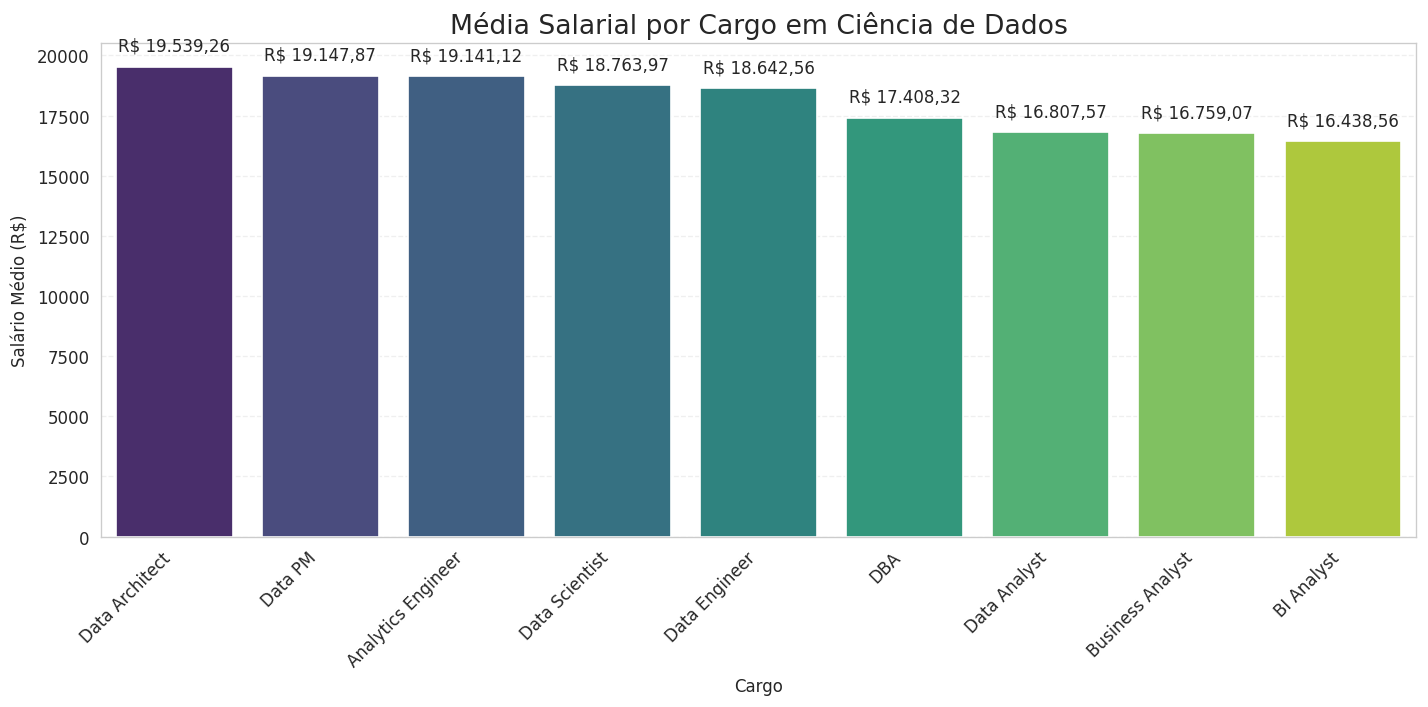

In [ ]:
#Plotagem do grafico Média Salarial por Cargo em Ciência de Dados
# Definir os cargos de interesse
cargos = [
    'Analytics_Engineer',
    'Engenharia_de_Dados/Data_Engineer',
    'Analista_de_Dados/Data_Analyst',
    'Cientista_de_Dados/Data_Scientist',
    'Database_Administrator/DBA',
    'Analista_de_Business_Intelligence/BI',
    'Arquiteto_de_Dados/Data_Architect',
    'Data_Product_Manager/DPM',
    'Business_Analyst'
]

# Criar um dicionário para armazenar as médias salariais
medias_salariais = {}

# Calcular a média salarial para cada cargo
for cargo in cargos:
    if cargo in merged_df.columns:
        # Filtrar apenas linhas onde o cargo é True e tem salário médio válido
        mask = (merged_df[cargo] == True) & (merged_df['Salario_Medio'].notna())
        media = merged_df.loc[mask, 'Salario_Medio'].mean()
        medias_salariais[cargo] = media

# Converter para DataFrame e ordenar
df_medias = pd.DataFrame.from_dict(medias_salariais, orient='index', columns=['Salario_Medio'])
df_medias = df_medias.sort_values('Salario_Medio', ascending=False)

# Simplificar os nomes dos cargos para o gráfico
nomes_simplificados = {
    'Analytics_Engineer': 'Analytics Engineer',
    'Engenharia_de_Dados/Data_Engineer': 'Data Engineer',
    'Analista_de_Dados/Data_Analyst': 'Data Analyst',
    'Cientista_de_Dados/Data_Scientist': 'Data Scientist',
    'Database_Administrator/DBA': 'DBA',
    'Analista_de_Business_Intelligence/BI': 'BI Analyst',
    'Arquiteto_de_Dados/Data_Architect': 'Data Architect',
    'Data_Product_Manager/DPM': 'Data PM',
    'Business_Analyst': 'Business Analyst'
}
df_medias.index = df_medias.index.map(nomes_simplificados)

# Plotar o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    x=df_medias.index,
    y=df_medias['Salario_Medio'],
    palette='viridis'
)

# Personalizar o gráfico
plt.title('Média Salarial por Cargo em Ciência de Dados', fontsize=16)
plt.xlabel('Cargo')
plt.ylabel('Salário Médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionar os valores nas barras
for i, valor in enumerate(df_medias['Salario_Medio']):
    plt.text(
        i,
        valor + 500,  # Ajuste este valor conforme necessário
        f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

<ipython-input-59-f75aebba3a58>:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


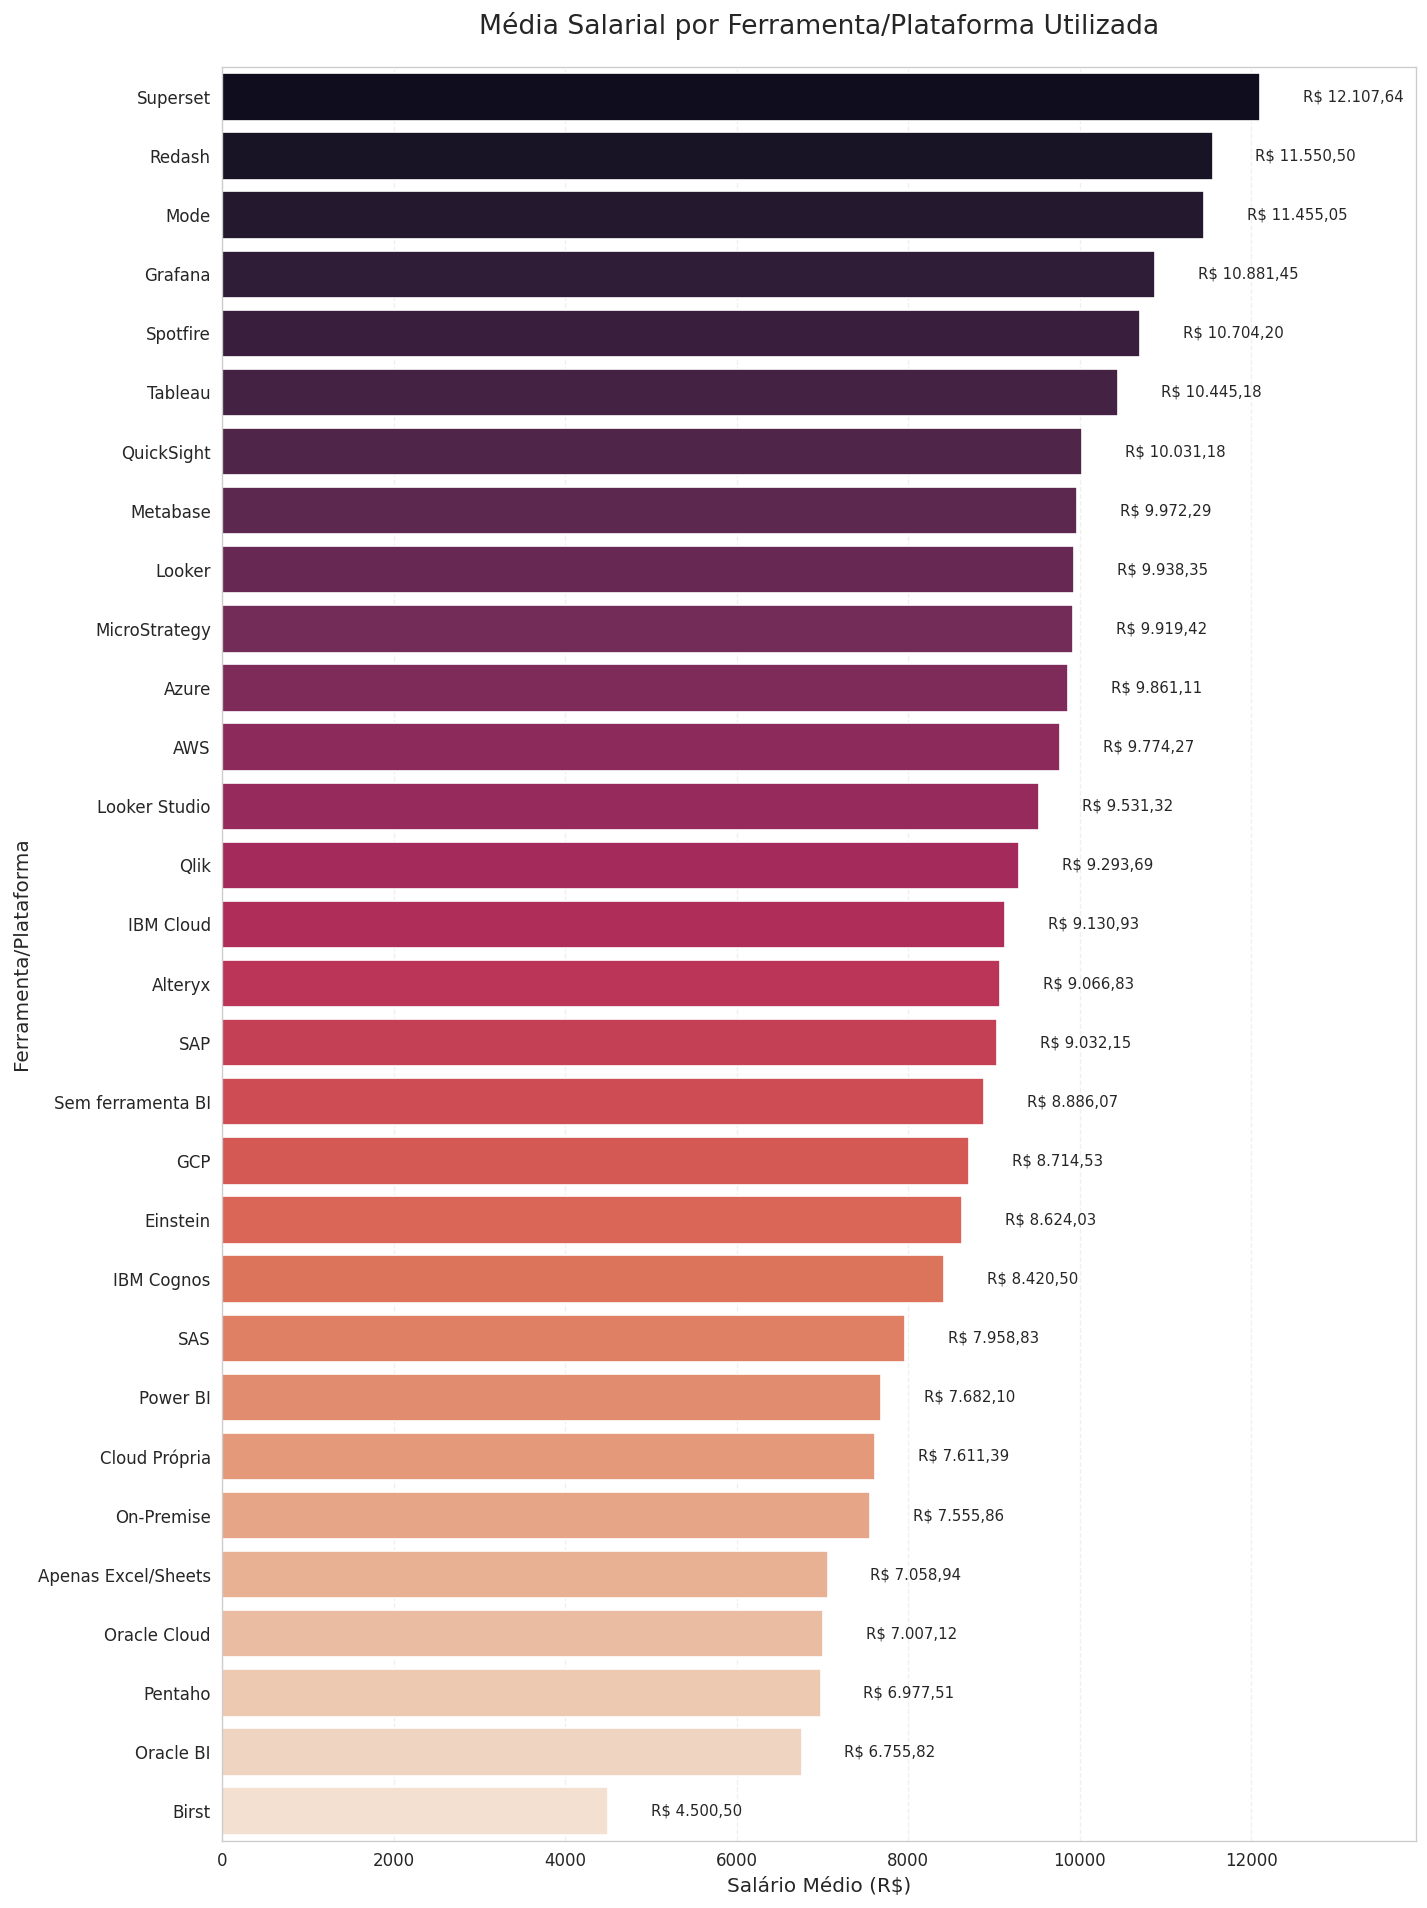

In [ ]:
#Plotagem do gráfico Média Salarial por Ferramenta/Plataforma Utilizada
# Lista completa de ferramentas incluindo os serviços de cloud
ferramentas = [
    'Azure (Microsoft)',
    'Amazon Web Services (AWS)',
    'Google Cloud (GCP)',
    'Oracle Cloud',
    'IBM',
    'Servidores On Premise/Não utilizamos Cloud',
    'Cloud Própria',
    'Microsoft PowerBI',
    'Qlik View/Qlik Sense',
    'Tableau',
    'Metabase',
    'Superset',
    'Redash',
    'Looker',
    'Looker Studio(Google Data Studio)',
    'Amazon Quicksight',
    'Mode',
    'Alteryx',
    'MicroStrategy',
    'IBM Analytics/Cognos',
    'SAP Business Objects/SAP Analytics',
    'Oracle Business Intelligence',
    'Salesforce/Einstein Analytics',
    'Birst',
    'SAS Visual Analytics',
    'Grafana',
    'TIBCO Spotfire',
    'Pentaho',
    'Fazemos todas as análises utilizando apenas Excel ou planilhas do google',
    'Não utilizo nenhuma ferramenta de BI no trabalho'
]

# Criar um dicionário para armazenar as médias salariais
medias_salariais = {}

# Calcular a média salarial para cada ferramenta
for ferramenta in ferramentas:
    if ferramenta in merged_df.columns:
        # Filtrar apenas linhas onde a ferramenta é True e tem salário médio válido
        mask = (merged_df[ferramenta] == True) & (merged_df['Salario_Medio'].notna())
        if mask.sum() > 0:  # Só calcula se houver dados
            media = merged_df.loc[mask, 'Salario_Medio'].mean()
            medias_salariais[ferramenta] = media

# Converter para DataFrame e ordenar
df_medias = pd.DataFrame.from_dict(medias_salariais, orient='index', columns=['Salario_Medio'])
df_medias = df_medias.sort_values('Salario_Medio', ascending=False)

# Dicionário para simplificar os nomes das ferramentas
nomes_simplificados = {
    'Azure (Microsoft)': 'Azure',
    'Amazon Web Services (AWS)': 'AWS',
    'Google Cloud (GCP)': 'GCP',
    'Oracle Cloud': 'Oracle Cloud',
    'IBM': 'IBM Cloud',
    'Servidores On Premise/Não utilizamos Cloud': 'On-Premise',
    'Cloud Própria': 'Cloud Própria',
    'Microsoft PowerBI': 'Power BI',
    'Qlik View/Qlik Sense': 'Qlik',
    'Tableau': 'Tableau',
    'Metabase': 'Metabase',
    'Superset': 'Superset',
    'Redash': 'Redash',
    'Looker': 'Looker',
    'Looker Studio(Google Data Studio)': 'Looker Studio',
    'Amazon Quicksight': 'QuickSight',
    'Mode': 'Mode',
    'Alteryx': 'Alteryx',
    'MicroStrategy': 'MicroStrategy',
    'IBM Analytics/Cognos': 'IBM Cognos',
    'SAP Business Objects/SAP Analytics': 'SAP',
    'Oracle Business Intelligence': 'Oracle BI',
    'Salesforce/Einstein Analytics': 'Einstein',
    'Birst': 'Birst',
    'SAS Visual Analytics': 'SAS',
    'Grafana': 'Grafana',
    'TIBCO Spotfire': 'Spotfire',
    'Pentaho': 'Pentaho',
    'Fazemos todas as análises utilizando apenas Excel ou planilhas do google': 'Apenas Excel/Sheets',
    'Não utilizo nenhuma ferramenta de BI no trabalho': 'Sem ferramenta BI'
}

# Aplicar os nomes simplificados
df_medias.index = df_medias.index.map(lambda x: nomes_simplificados.get(x, x))

# Plotar o gráfico (versão horizontal para melhor visualização)
plt.figure(figsize=(12, 16))
barplot = sns.barplot(
    y=df_medias.index,
    x=df_medias['Salario_Medio'],
    palette='rocket',
    orient='h'
)

# Personalizar o gráfico
plt.title('Média Salarial por Ferramenta/Plataforma Utilizada', fontsize=16, pad=20)
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('Ferramenta/Plataforma', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Adicionar os valores nas barras formatados em R$
for p in barplot.patches:
    width = p.get_width()
    plt.text(
        width + 500,  # Offset para não sobrepor a barra
        p.get_y() + p.get_height()/2,
        f'R$ {width:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        va='center',
        fontsize=9
    )

# Ajustar os limites do eixo x para acomodar os textos
plt.xlim(right=df_medias['Salario_Medio'].max() * 1.15)

plt.tight_layout()
plt.show()

<ipython-input-60-d1f798fb4c4a>:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


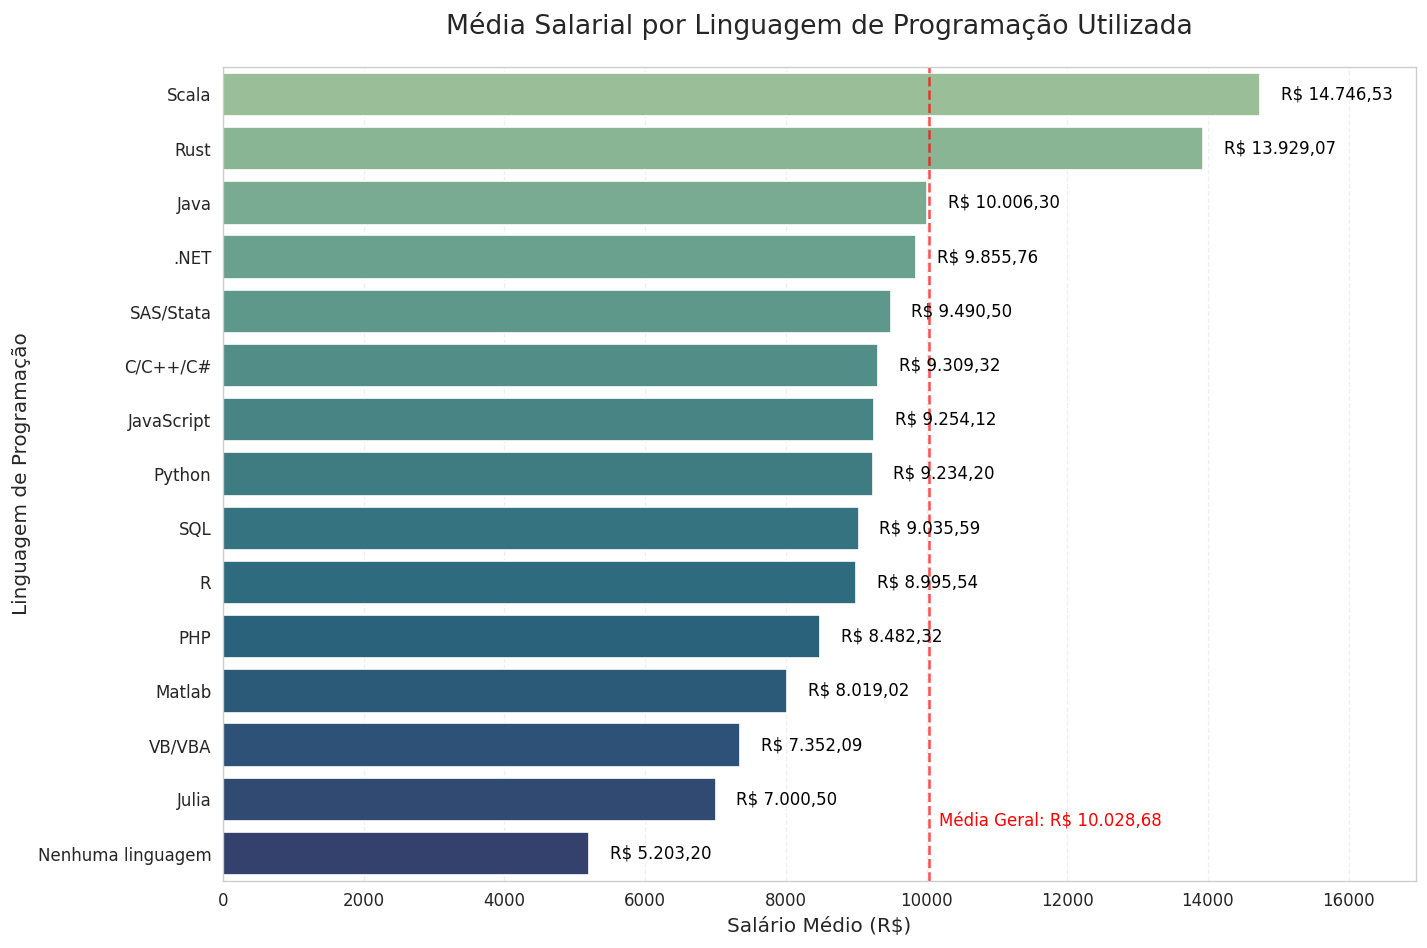

In [ ]:
#Plotagem do gráfico Média Salarial por Linguagem de Programação Utilizada
# Definir as linguagens de programação
linguagens = [
    'SQL',
    'R',
    'Python',
    'C/C++/C#',
    'NET',
    'Java',
    'Julia',
    'SAS/Stata',
    'Visual Basic/VBA',
    'Scala',
    'Matlab',
    'Rust',
    'PHP',
    'JavaScript',
    'Não utilizo nenhuma linguagem'
]

# Criar um dicionário para armazenar as médias salariais
medias_salariais = {}

# Calcular a média salarial para cada linguagem
for linguagem in linguagens:
    if linguagem in merged_df.columns:
        # Filtrar apenas linhas onde a linguagem é True e tem salário médio válido
        mask = (merged_df[linguagem] == True) & (merged_df['Salario_Medio'].notna())
        if mask.sum() > 0:  # Só calcula se houver dados
            media = merged_df.loc[mask, 'Salario_Medio'].mean()
            medias_salariais[linguagem] = media

# Converter para DataFrame e ordenar
df_medias = pd.DataFrame.from_dict(medias_salariais, orient='index', columns=['Salario_Medio'])
df_medias = df_medias.sort_values('Salario_Medio', ascending=False)

# Simplificar os nomes das linguagens para o gráfico
nomes_simplificados = {
    'SQL': 'SQL',
    'R': 'R',
    'Python': 'Python',
    'C/C++/C#': 'C/C++/C#',
    'NET': '.NET',
    'Java': 'Java',
    'Julia': 'Julia',
    'SAS/Stata': 'SAS/Stata',
    'Visual Basic/VBA': 'VB/VBA',
    'Scala': 'Scala',
    'Matlab': 'Matlab',
    'Rust': 'Rust',
    'PHP': 'PHP',
    'JavaScript': 'JavaScript',
    'Não utilizo nenhuma linguagem': 'Nenhuma linguagem'
}
df_medias.index = df_medias.index.map(nomes_simplificados)

# Plotar o gráfico (versão horizontal para melhor visualização)
plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    y=df_medias.index,
    x=df_medias['Salario_Medio'],
    palette='crest',
    orient='h'
)

# Personalizar o gráfico
plt.title('Média Salarial por Linguagem de Programação Utilizada', fontsize=16, pad=20)
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('Linguagem de Programação', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Adicionar os valores nas barras formatados em R$
for p in barplot.patches:
    width = p.get_width()
    plt.text(
        width + (df_medias['Salario_Medio'].max() * 0.02),  # Offset de 2% do valor máximo
        p.get_y() + p.get_height()/2,
        f'R$ {width:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        va='center',
        fontsize=10,
        color='black'
    )

# Ajustar os limites do eixo x para acomodar os textos
plt.xlim(right=df_medias['Salario_Medio'].max() * 1.15)

# Adicionar linha vertical na média geral
media_geral = merged_df['Salario_Medio'].mean()
plt.axvline(media_geral, color='red', linestyle='--', alpha=0.7)
plt.text(
    media_geral + (df_medias['Salario_Medio'].max() * 0.01),
    len(df_medias) * 0.9,
    f'Média Geral: R$ {media_geral:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
    color='red'
)

plt.tight_layout()
plt.show()


<ipython-input-61-5134ab1a71c1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


,Setor,Salario_Medio,Quantidade
6,Internet/Ecommerce,R$ 11748.50,125
2,Entretenimento ou Esportes,R$ 11560.84,58
12,Setor Farmaceutico,R$ 11155.67,29
4,Finanças ou Bancos,R$ 10935.40,914
9,Seguros ou Previdência,R$ 10676.97,68
16,Tecnologia/Fábrica de Software,R$ 10632.45,834
18,Varejo,R$ 10567.25,382
19,Área da Saúde,R$ 9945.50,200
14,Setor Público,R$ 9726.97,170
15,Setor de Energia,R$ 9607.64,84


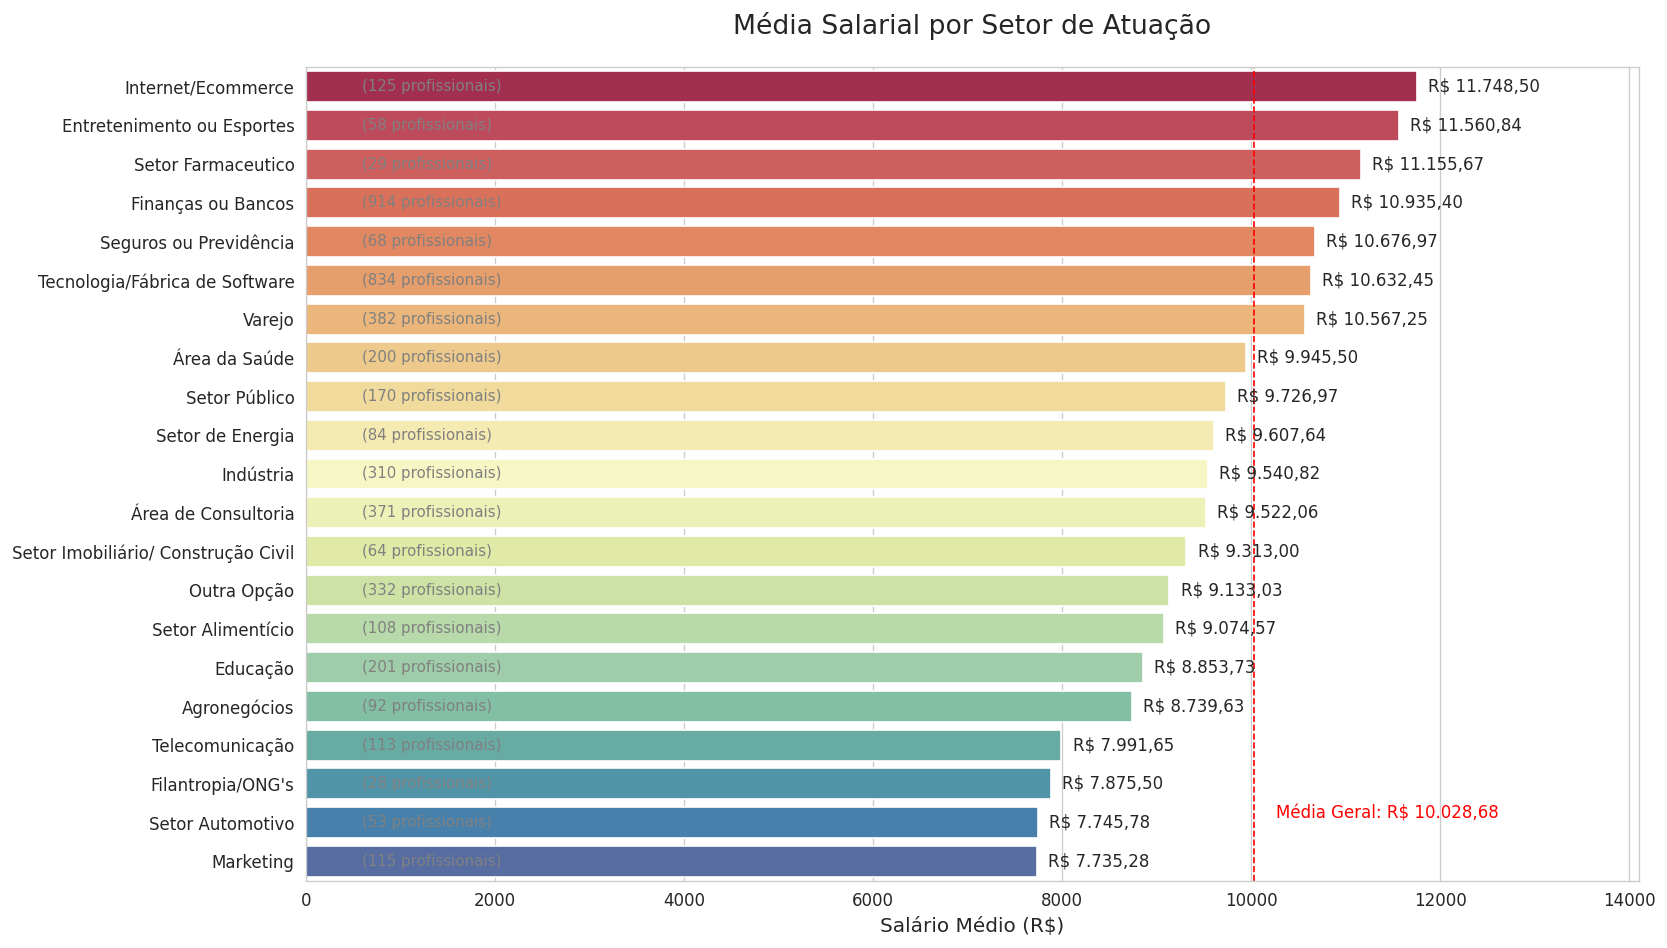

In [ ]:
#Plotagem do gráfico Média Salarial por Setor de Atuação
# Lista completa de setores
setores = [
    'Agronegócios',
    'Educação',
    'Entretenimento ou Esportes',
    'Filantropia/ONG\'s',
    'Finanças ou Bancos',
    'Indústria',
    'Internet/Ecommerce',
    'Marketing',
    'Outra Opção',
    'Seguros ou Previdência',
    'Setor Alimentício',
    'Setor Automotivo',
    'Setor Farmaceutico',
    'Setor Imobiliário/ Construção Civil',
    'Setor Público',
    'Setor de Energia',
    'Tecnologia/Fábrica de Software',
    'Telecomunicação',
    'Varejo',
    'Área da Saúde',
    'Área de Consultoria'
]

# Criar DataFrame filtrado
df_setores = merged_df[merged_df['Setor'].isin(setores) & merged_df['Salario_Medio'].notna()]

# Calcular média salarial por setor
media_setores = df_setores.groupby('Setor')['Salario_Medio'].agg(['mean', 'count']).reset_index()
media_setores.columns = ['Setor', 'Salario_Medio', 'Quantidade']
media_setores = media_setores.sort_values('Salario_Medio', ascending=False)

# Configurações do gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Paleta de cores personalizada
cores = sns.color_palette("Spectral", len(media_setores))

# Gráfico de barras
barplot = sns.barplot(
    data=media_setores,
    y='Setor',
    x='Salario_Medio',
    palette=cores,
    orient='h'
)

# Adicionar valores e customização
for i, (salario, count) in enumerate(zip(media_setores['Salario_Medio'], media_setores['Quantidade'])):
    plt.text(
        salario + (media_setores['Salario_Medio'].max() * 0.01),
        i,
        f'R$ {salario:,.2f}'.replace('.', '|').replace(',', '.').replace('|', ','),
        va='center',
        fontsize=10
    )

    # Adicionar contagem de profissionais
    plt.text(
        media_setores['Salario_Medio'].max() * 0.05,  # Posição fixa à esquerda
        i,
        f'({count} profissionais)',
        va='center',
        fontsize=9,
        color='gray'
    )

# Linha da média geral
media_geral = df_setores['Salario_Medio'].mean()
plt.axvline(media_geral, color='red', linestyle='--', linewidth=1)
plt.text(
    media_geral + (media_setores['Salario_Medio'].max() * 0.02),
    len(media_setores) * 0.9,
    f'Média Geral: R$ {media_geral:,.2f}'.replace('.', '|').replace(',', '.').replace('|', ','),
    color='red'
)

# Ajustes finais
plt.title('Média Salarial por Setor de Atuação', fontsize=16, pad=20)
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('')
plt.xlim(right=media_setores['Salario_Medio'].max() * 1.2)
plt.tight_layout()

# Mostrar tabela com os dados
display(media_setores.style.format({
    'Salario_Medio': 'R$ {:.2f}',
    'Quantidade': '{:.0f}'
}).background_gradient(cmap='Blues', subset=['Salario_Medio']))

plt.show()

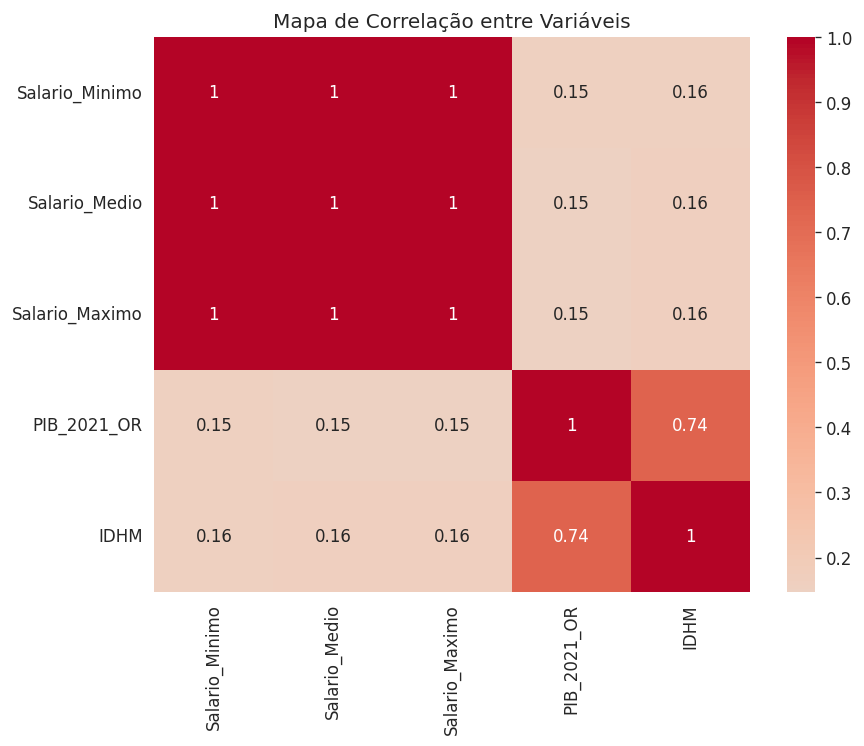

In [ ]:
#Plotagem da corelação Mapa de Correlação entre Variáveis
correlation = merged_df[['Salario_Minimo', 'Salario_Medio', 'Salario_Maximo', 'PIB_2021_OR', 'IDHM']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de Correlação entre Variáveis')
plt.show()

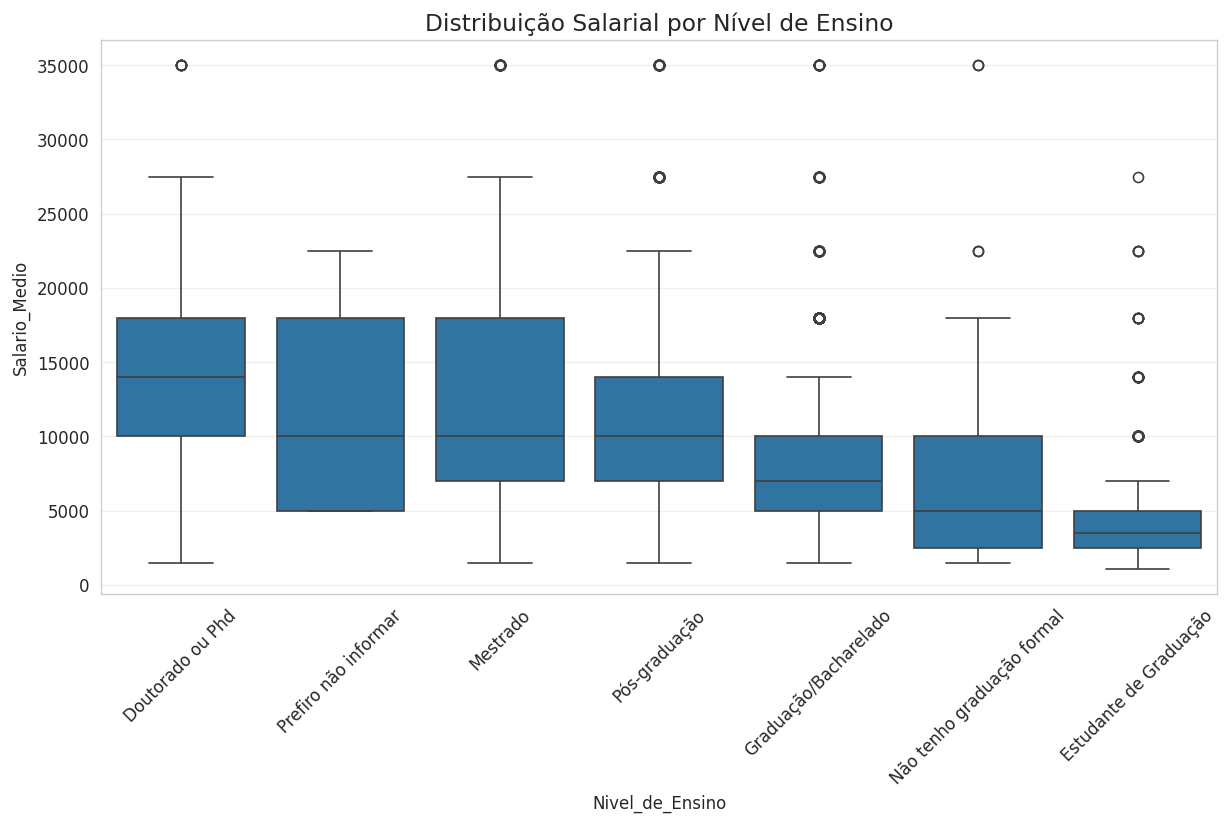

In [ ]:
#Plotagem do gráfico Distribuição Salarial por Nível de Ensino
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=merged_df,
    x='Nivel_de_Ensino',
    y='Salario_Medio',
    order=merged_df.groupby('Nivel_de_Ensino')['Salario_Medio'].median().sort_values(ascending=False).index
)
plt.title('Distribuição Salarial por Nível de Ensino', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

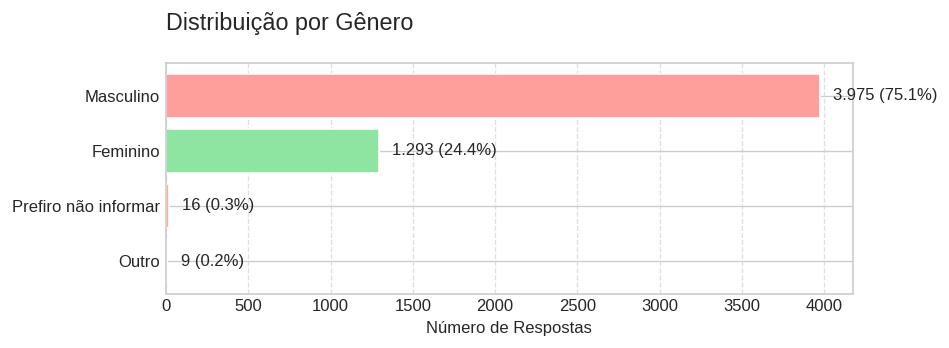

In [ ]:
#Plotagem do gráfico Distribuição por Gênero
# Configurações
plt.figure(figsize=(8, 3))
plt.style.use('seaborn-v0_8-whitegrid')

# Dados
genero_counts = merged_df['Genero'].value_counts().sort_values(ascending=True)  # Ordenar do menor para maior

# Gráfico de barras horizontais
bars = plt.barh(
    genero_counts.index,
    genero_counts.values,
    color=sns.color_palette('pastel', len(genero_counts))
)  # Parênteses fechado corretamente aqui

plt.title('Distribuição por Gênero', fontsize=14, pad=20, loc='left')
plt.xlabel('Número de Respostas')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Adicionar valores e porcentagens nas barras
for bar in bars:
    width = bar.get_width()
    porcentagem = 100 * width / sum(genero_counts)
    plt.text(
        width + (0.02 * max(genero_counts.values)),  # Offset proporcional
        bar.get_y() + bar.get_height()/2,
        f'{width:,} ({porcentagem:.1f}%)'.replace(',', '.'),
        va='center',
        fontsize=10
    )

# Ajustes finais
plt.tight_layout()
plt.show()

<ipython-input-77-db57e7a353f3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='Uf', y='Salario_Medio', palette='rocket')


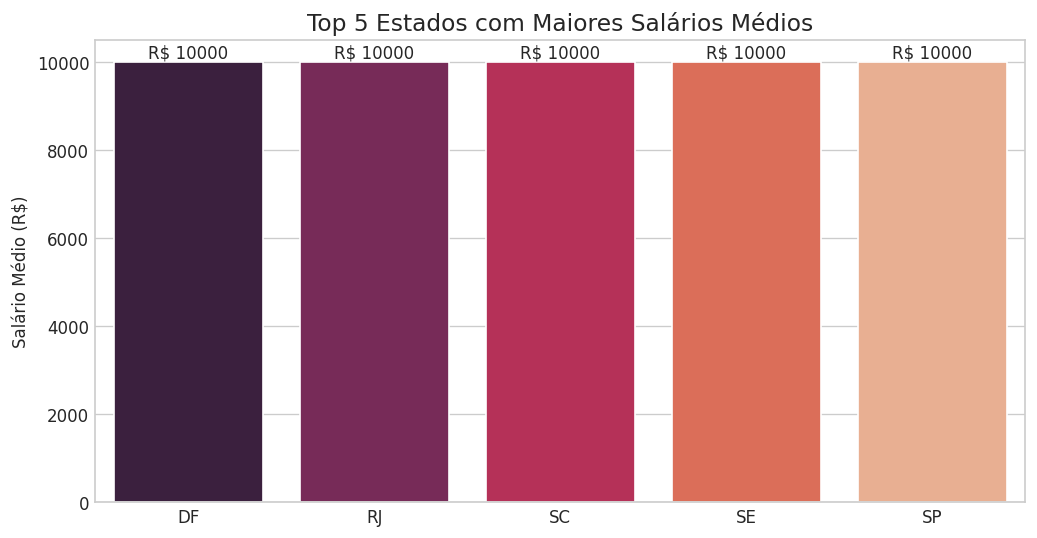

In [ ]:
#Plotagem do gráfico Top 5 Estados com Maiores Salários Médios
top5 = merged_df.groupby('Uf')['Salario_Medio'].median().nlargest(5).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=top5, x='Uf', y='Salario_Medio', palette='rocket')
plt.title('Top 5 Estados com Maiores Salários Médios', fontsize=14)
plt.xlabel('')
plt.ylabel('Salário Médio (R$)')
for i, v in enumerate(top5['Salario_Medio']):
    plt.text(i, v + 100, f'R$ {v:.0f}', ha='center')
plt.show()

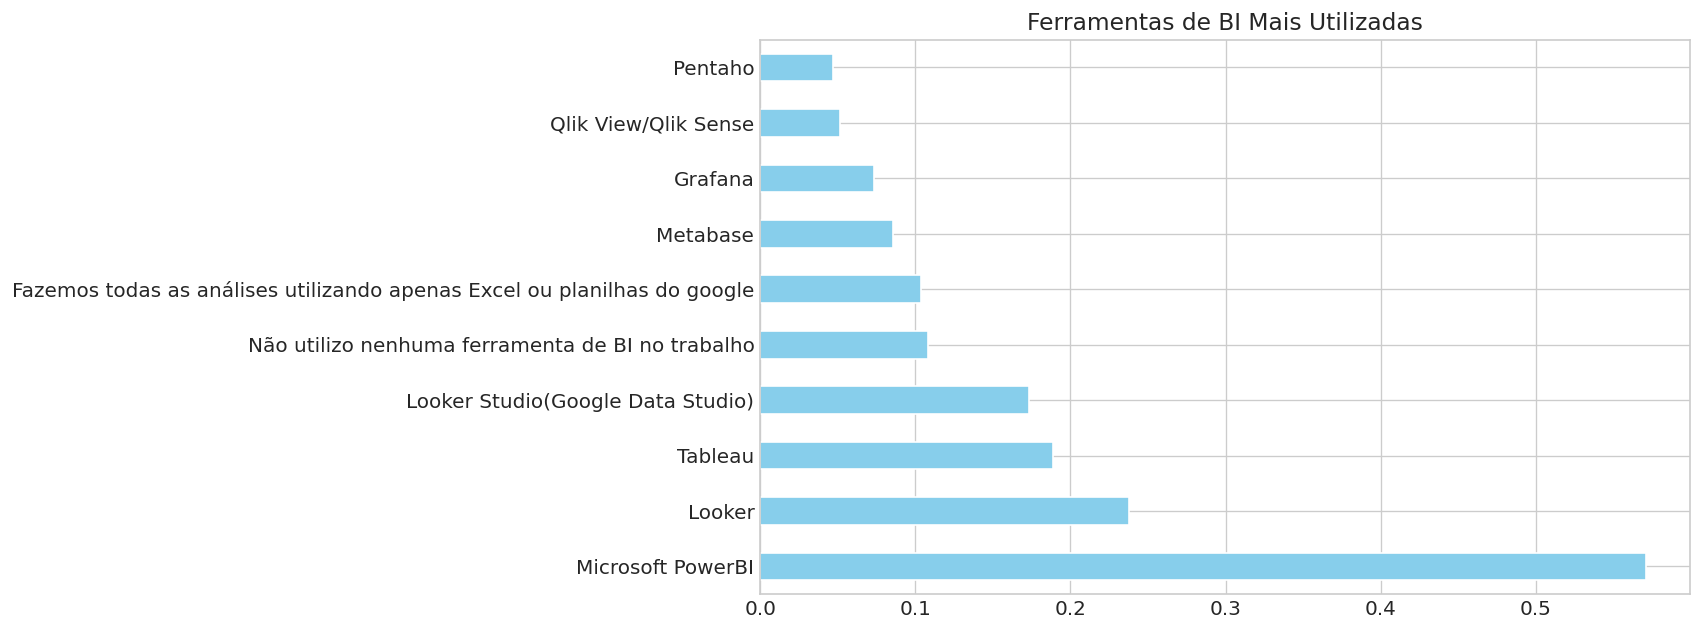

In [ ]:
#Plotagem do grafico do Salário Médio por UF e Gênero
ferramentas = merged_df.iloc[:, 55:78].mean().sort_values(ascending=False)[:10]
ferramentas.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Ferramentas de BI Mais Utilizadas', fontsize=14)
plt.show()

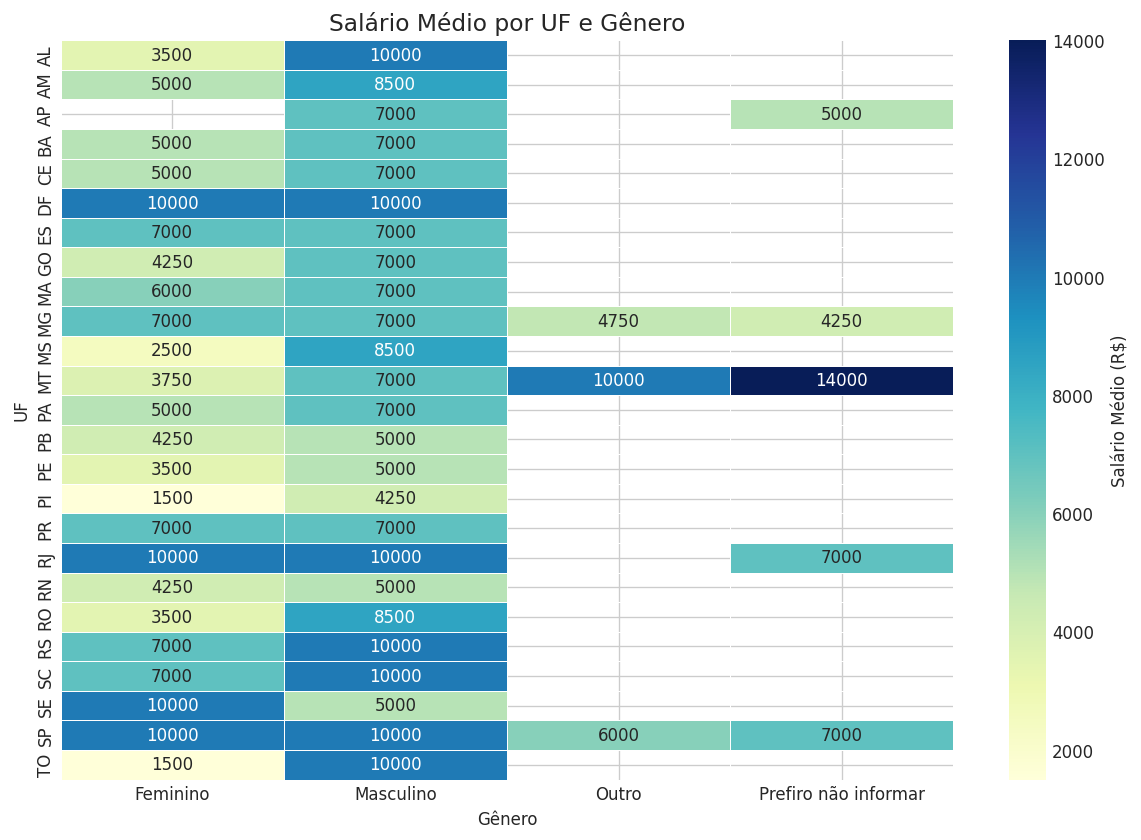

In [ ]:
#Plotagem do gráfico Salário Médio por UF e Gênero
heatmap_data = merged_df.pivot_table(
    index='Uf',
    columns='Genero',
    values='Salario_Medio',
    aggfunc='median'
)

# Plotar
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Salário Médio (R$)'}
)
plt.title('Salário Médio por UF e Gênero', fontsize=14)
plt.xlabel('Gênero')
plt.ylabel('UF')
plt.show()

<ipython-input-83-e93a9dc62cdc>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


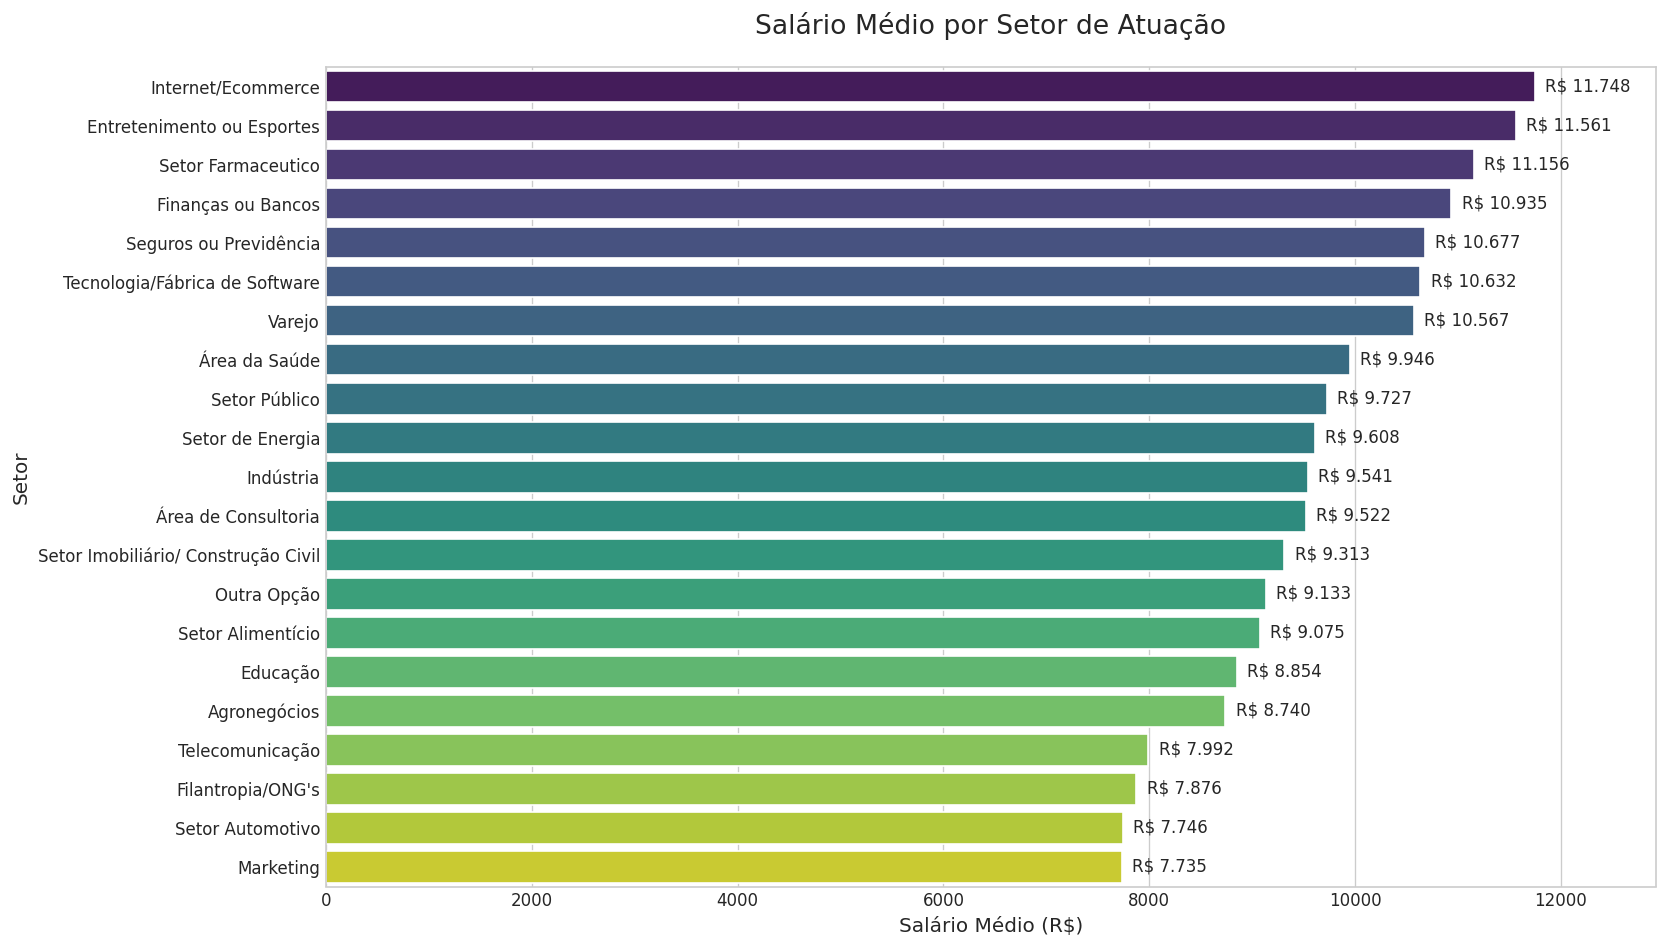

In [ ]:
#Salário Médio por Setor de Atuação
# 1. Preparação dos dados - calcular salário médio por setor
salario_por_setor = merged_df.groupby('Setor')['Salario_Medio'].mean().sort_values(ascending=False).reset_index()

# 2. Configurações do gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
barplot = sns.barplot(
    data=salario_por_setor,
    x='Salario_Medio',
    y='Setor',
    palette='viridis',
    estimator='mean',
    errorbar=None
)

# 4. Personalizações
plt.title('Salário Médio por Setor de Atuação', fontsize=16, pad=20)
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('Setor', fontsize=12)
plt.xlim(0, salario_por_setor['Salario_Medio'].max() * 1.1)  # Espaço extra para os valores

# 5. Adicionar valores nas barras
for p in barplot.patches:
    width = p.get_width()
    plt.text(
        width + 100,  # Posição x (salário + pequeno offset)
        p.get_y() + p.get_height()/2,  # Posição y (centro da barra)
        f'R$ {width:,.0f}'.replace(',', '.'),  # Formatação do valor
        ha='left',
        va='center',
        fontsize=10
    )

# 6. Ajustes finais
plt.tight_layout()
plt.show()

<ipython-input-84-73a7ece8c41a>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


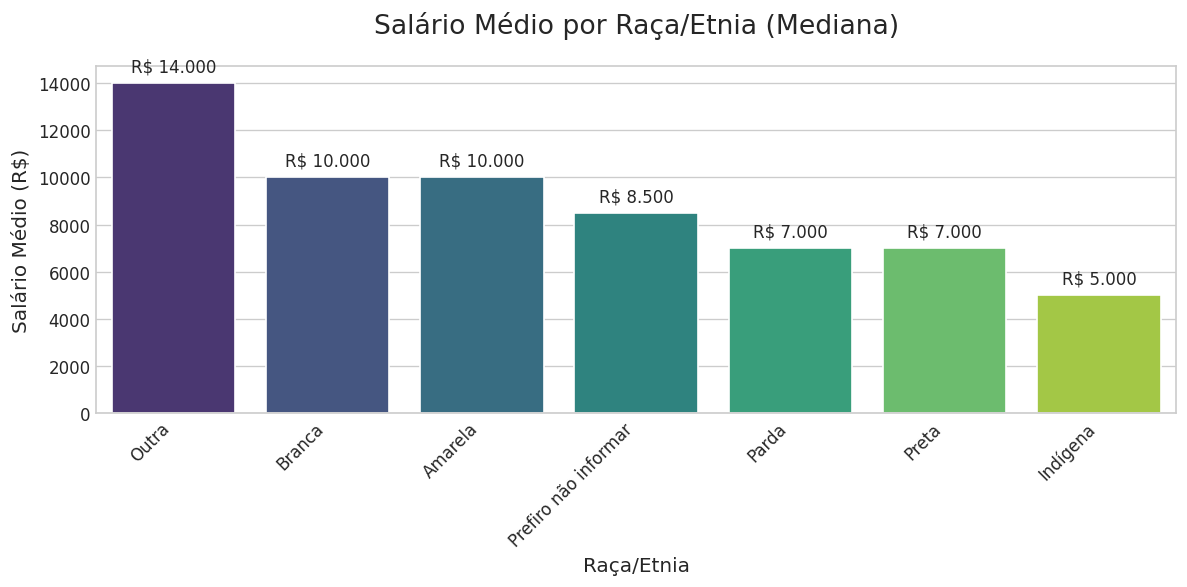

In [ ]:
#Plotagem do grafico Salário Médio por Raça/Etnia (Mediana)
# Configurações de estilo CORRIGIDAS
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# Filtrar dados e calcular médias
salario_raca = merged_df.groupby('Cor/Raça/Etnia')['Salario_Medio'].median().sort_values(ascending=False)

# Gráfico de colunas
ax = sns.barplot(
    x=salario_raca.index,
    y=salario_raca.values,
    palette='viridis',
    estimator='median',
    errorbar=None
)

# Personalização
plt.title('Salário Médio por Raça/Etnia (Mediana)', fontsize=16, pad=20)
plt.xlabel('Raça/Etnia', fontsize=12)
plt.ylabel('Salário Médio (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adicionar valores nas colunas
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():,.0f}'.replace(',', '.'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points')

plt.tight_layout()
plt.show()

<ipython-input-85-816e1c6d61ec>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


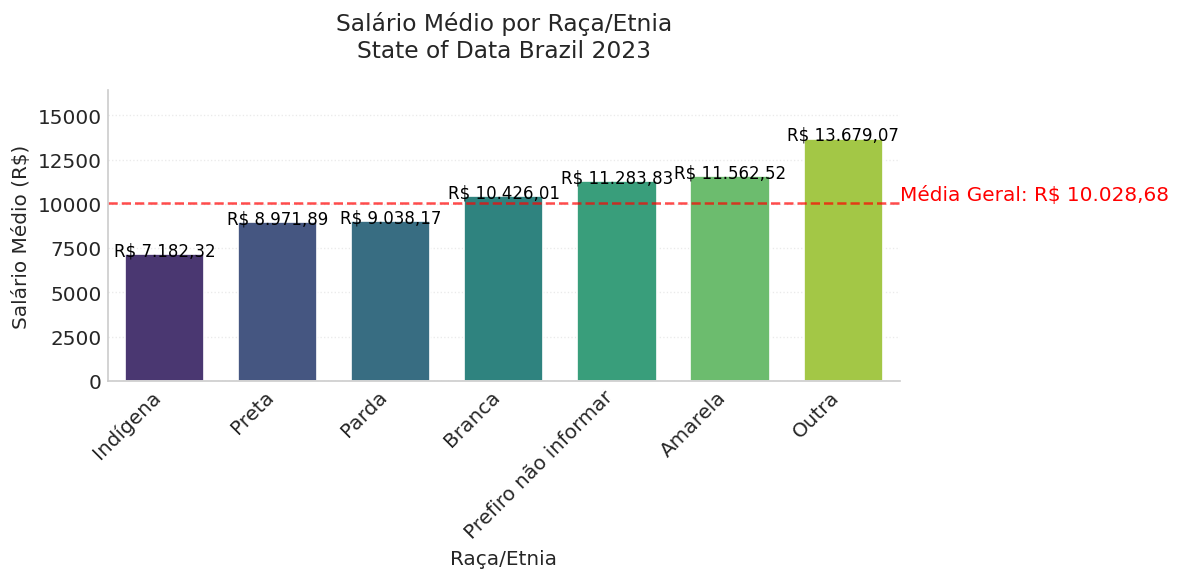

In [ ]:
#Plotagem do gráfico Salário Médio por Raça/Etnia\nState of Data Brazil 2023

# Configurações do gráfico
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# 1. Calcular média salarial por raça (ordenado)
salario_por_raca = merged_df.groupby('Cor/Raça/Etnia')['Salario_Medio'].mean()\
                           .sort_values(ascending=True)  # Ordem crescente para melhor visualização

# 2. Criar gráfico de colunas
ax = sns.barplot(
    x=salario_por_raca.index,
    y=salario_por_raca.values,
    palette='viridis',  # Paleta de cores
    width=0.7          # Largura das colunas
)

# 3. Adicionar rótulos formatados
for p in ax.patches:
    ax.annotate(
        f'R$ {p.get_height():,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),  # Formato BRL
        (p.get_x() + p.get_width() / 2., p.get_height() + 200),  # Posição (x, y)
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

# 4. Linha da média geral
media_geral = merged_df['Salario_Medio'].mean()
plt.axhline(media_geral, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(
    len(salario_por_raca) - 0.5,
    media_geral + 200,
    f'Média Geral: R$ {media_geral:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
    color='red'
)

# 5. Customização
plt.title('Salário Médio por Raça/Etnia\nState of Data Brazil 2023', fontsize=14, pad=20)
plt.xlabel('Raça/Etnia', fontsize=12)
plt.ylabel('Salário Médio (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotacionar labels do eixo X
plt.ylim(top=salario_por_raca.max() * 1.2)

# 6. Melhorias visuais
sns.despine()
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

<ipython-input-100-c8138e27a2ba>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


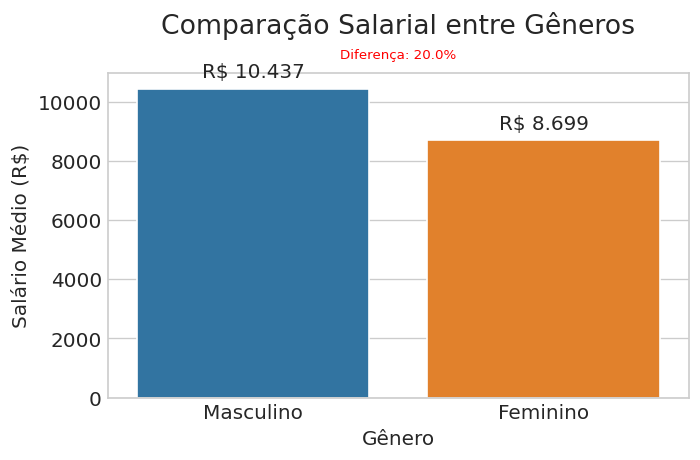

In [ ]:
#Plotar gráfico Comparação Salarial entre Gêneros
# Filtrar apenas masculino e feminino
df_genero = merged_df[merged_df['Genero'].isin(['Masculino', 'Feminino'])]

plt.figure(figsize=(6, 4))

# Gráfico de colunas
ax = sns.barplot(
    data=df_genero,
    x='Genero',
    y='Salario_Medio',
    palette=['#1f77b4', '#ff7f0e'],  # Azul e laranja
    estimator='mean',
    errorbar=None
)

# Personalização
plt.title('Comparação Salarial entre Gêneros', fontsize=16, pad=24)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Salário Médio (R$)', fontsize=12)

# Adicionar valores e linha de diferença
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():,.0f}'.replace(',', '.'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points')

# Calcular diferença percentual
salario_m = df_genero[df_genero['Genero'] == 'Masculino']['Salario_Medio'].mean()
salario_f = df_genero[df_genero['Genero'] == 'Feminino']['Salario_Medio'].mean()
diferenca = ((salario_m - salario_f) / salario_f) * 100

plt.text(0.5, max(salario_m, salario_f) * 1.1,
         f'Diferença: {diferenca:.1f}%',
         ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# Converter o DataFrame para CSV e baixar
merged_df.to_csv('dados.csv', index=False, encoding='utf-8-sig')  # index=False evita uma coluna extra de índices
files.download('dados.csv')  # Inicia o download automaticamente

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dados = pd.read_csv('dados.csv')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 95 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Idade                                                                     5293 non-null   int64  
 1   Faixa de idade                                                            5293 non-null   object 
 2   Genero                                                                    5293 non-null   object 
 3   Cor/Raça/Etnia                                                            5293 non-null   object 
 4   PDC                                                                       5293 non-null   object 
 5   Estado_onde_mora                                                          5172 non-null   object 
 6   Uf                                                              

In [ ]:
import pandas as pd
import numpy as np

# Supondo que 'dados' já seja um DataFrame do pandas carregado.
# Se 'dados' for o nome de um arquivo (ex: 'dados.csv'),
# você precisaria carregá-lo primeiro:
# dados = pd.read_csv('dados.csv')

# --- 0. Cópia de Segurança (Opcional, mas recomendado) ---
# Para não modificar o DataFrame original
df = dados.copy()

print("--- Informações Iniciais ---")
print(f"Shape inicial: {df.shape}")
df.info()
print("\n")

# --- 1. Seleção dos Atributos ---
# Selecionar as colunas relevantes para a pergunta
colunas_relevantes = ['Salario_Medio', 'PIB_2021_OR', 'IDHM', 'Uf']
df_selecionado = df[colunas_relevantes].copy() # Usar .copy() para evitar SettingWithCopyWarning

print("--- Após Seleção de Colunas ---")
print(f"Shape após seleção: {df_selecionado.shape}")
print("Colunas selecionadas:")
print(df_selecionado.head())
print("\n")

# --- 2. Tratamento de Valores Faltantes ---
# Verificar valores faltantes nas colunas selecionadas
print("--- Tratamento de Valores Faltantes ---")
print("Valores faltantes antes do tratamento:")
print(df_selecionado.isnull().sum())

# Estratégia: Remover linhas onde qualquer uma das colunas essenciais (Salario_Medio, PIB_2021_OR, IDHM, Uf)
# tenha valor faltante, pois são cruciais para a análise de correlação.
# A coluna 'Uf' é necessária para garantir que PIB e IDH correspondam ao local de trabalho.
# Se 'Salario_Medio' estiver faltando, não podemos analisar o salário.
# Se 'PIB_2021_OR' ou 'IDHM' estiverem faltando (e 'Uf' presente), indica uma falha nos dados originais.
df_sem_na = df_selecionado.dropna(subset=colunas_relevantes)

print("\nValores faltantes após remoção (dropna):")
print(df_sem_na.isnull().sum())
print(f"Shape após remoção de NA: {df_sem_na.shape}")
print("\n")

# --- 3. Tratamento de Valores Inconsistentes ---
print("--- Tratamento de Valores Inconsistentes ---")

# 3a. Remoção de Dados Duplicados
# Verificar se há linhas completamente duplicadas nas colunas selecionadas
duplicados_antes = df_sem_na.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {duplicados_antes}")

if duplicados_antes > 0:
    df_sem_duplicados = df_sem_na.drop_duplicates()
    print(f"Shape após remoção de duplicados: {df_sem_duplicados.shape}")
else:
    df_sem_duplicados = df_sem_na # Nenhuma duplicata para remover
    print("Nenhuma linha duplicada removida.")

# 3b. Tratamento de Outliers (Exemplo usando IQR para Salario_Medio)
# Outliers em PIB e IDH podem ser menos prováveis de serem erros e mais
# representativos das diferenças reais entre estados, mas outliers em Salário
# podem distorcer a correlação. Vamos focar em 'Salario_Medio'.

print("\nTratamento de Outliers para 'Salario_Medio':")
Q1 = df_sem_duplicados['Salario_Medio'].quantile(0.25)
Q3 = df_sem_duplicados['Salario_Medio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"  Q1 (Salario_Medio): {Q1}")
print(f"  Q3 (Salario_Medio): {Q3}")
print(f"  IQR (Salario_Medio): {IQR}")
print(f"  Limite Inferior para outliers: {limite_inferior}")
print(f"  Limite Superior para outliers: {limite_superior}")

# Contar outliers
outliers = df_sem_duplicados[
    (df_sem_duplicados['Salario_Medio'] < limite_inferior) |
    (df_sem_duplicados['Salario_Medio'] > limite_superior)
]
print(f"  Número de outliers detectados em 'Salario_Medio': {len(outliers)}")

# Estratégia: Remover os outliers de 'Salario_Medio'
df_sem_outliers = df_sem_duplicados[
    (df_sem_duplicados['Salario_Medio'] >= limite_inferior) &
    (df_sem_duplicados['Salario_Medio'] <= limite_superior)
]

print(f"Shape após remoção de outliers de Salario_Medio: {df_sem_outliers.shape}")
print("\n")

# 3c. Conversão de Tipos (Verificação)
# Vamos verificar se os tipos de dados estão corretos para análise numérica.
print("Verificação dos tipos de dados:")
print(df_sem_outliers.dtypes)
# Salario_Medio, PIB_2021_OR, IDHM devem ser numéricos (float ou int).
# Uf deve ser object (string).
# Se algum tipo precisar ser convertido (ex: Salario_Medio estivesse como object),
# seria feito aqui usando pd.to_numeric. Exemplo:
# df_sem_outliers['Salario_Medio'] = pd.to_numeric(df_sem_outliers['Salario_Medio'], errors='coerce')
# E depois tratar possíveis NaNs introduzidos pelo 'coerce'.
# No nosso caso, os tipos já parecem corretos com base no info() inicial.

# --- 4. Conversão de Dados ---
# Para a pergunta específica de correlação entre variáveis numéricas (Salário, PIB, IDH),
# geralmente não precisamos de conversões adicionais como numérico para categórico
# ou categórico para binário. As colunas já estão no formato adequado (numérico).
# A coluna 'Uf' é categórica, mas serve como identificador e não entrará diretamente
# na matriz de correlação numérica (a não ser que fosse convertida para dummy,
# o que não é o objetivo aqui).

print("--- Conversão de Dados ---")
print("Nenhuma conversão adicional necessária para a análise de correlação numérica.")
print("\n")

# --- Finalização ---
# O DataFrame final preparado para a análise de correlação
df_preparado = df_sem_outliers.copy()

print("--- Dados Preparados ---")
print(f"Shape final do DataFrame preparado: {df_preparado.shape}")
print("Primeiras linhas do DataFrame preparado:")
print(df_preparado.head())
print("\nInformações do DataFrame preparado:")
df_preparado.info()
print("\nEstatísticas descritivas do DataFrame preparado:")
print(df_preparado.describe())

# Agora, o DataFrame 'df_preparado' está pronto.
# O próximo passo seria calcular a correlação, por exemplo:
# matriz_correlacao = df_preparado[['Salario_Medio', 'PIB_2021_OR', 'IDHM']].corr()
# print("\nMatriz de Correlação:")
# print(matriz_correlacao)

--- Informações Iniciais ---
Shape inicial: (5293, 95)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 95 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Idade                                                                     5293 non-null   int64  
 1   Faixa de idade                                                            5293 non-null   object 
 2   Genero                                                                    5293 non-null   object 
 3   Cor/Raça/Etnia                                                            5293 non-null   object 
 4   PDC                                                                       5293 non-null   object 
 5   Estado_onde_mora                                                          5172 non-null   object 
 6   Uf       

In [ ]:
valores_unicos = df['Tempo_de_experiencia_agrupado'].unique()
print(valores_unicos)

['de 3 a 4 anos' 'de 1 a 2 anos' nan 'Menos de 1 ano' 'de 7 a 10 anos'
 'Mais de 10 anos' 'de 4 a 6 anos'
 'Não tenho experiência na área de dados']


In [ ]:
valores_unicos = df['Nivel_de_Ensino'].unique()
print(valores_unicos)

['Doutorado ou Phd' 'Graduação/Bacharelado' 'Estudante de Graduação'
 'Pós-graduação' 'Mestrado' 'Não tenho graduação formal'
 'Prefiro não informar']


In [ ]:
valores_unicos = df['Setor'].unique()
print(valores_unicos)

['Finanças ou Bancos' nan 'Outra Opção' 'Tecnologia/Fábrica de Software'
 'Varejo' 'Setor Público' 'Entretenimento ou Esportes'
 'Internet/Ecommerce' 'Área da Saúde' 'Área de Consultoria'
 'Setor Alimentício' 'Educação' 'Marketing' 'Indústria' 'Setor Automotivo'
 'Agronegócios' 'Seguros ou Previdência' 'Setor de Energia'
 'Setor Imobiliário/ Construção Civil' "Filantropia/ONG's"
 'Telecomunicação' 'Setor Farmaceutico']


In [ ]:
experiencia_order = [
    'Não tenho experiência na área de dados',
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 4 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos'
]

In [ ]:
ensino_order = [
    'Não tenho graduação formal',
    'Estudante de Graduação',
    'Graduação/Bacharelado',
    'Pós-graduação',
    'Mestrado',
    'Doutorado ou Phd',
    'Prefiro não informar'  # Tratar como missing ou categoria separada
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Definir os pré-processadores para cada tipo de variável
preprocessor = ColumnTransformer(
    transformers=[
        # Variáveis numéricas (apenas passar adiante)
        ('num', 'passthrough', ['PIB_2021_OR', 'IDHM']),

        # Tempo de experiência (ordinal com imputação de missing)
        ('exp', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Não tenho experiência na área de dados')),
            ('encoder', OrdinalEncoder(categories=[experiencia_order]))
        ]), ['Tempo_de_experiencia_agrupado']),

        # Nível de ensino (ordinal com imputação)
        ('ensino', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Prefiro não informar')),
            ('encoder', OrdinalEncoder(categories=[ensino_order]))
        ]), ['Nivel_de_Ensino']),

        # Setor (one-hot com imputação)
        ('setor', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Outra Opção')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), ['Setor'])
    ],
    remainder='drop'  # Ignorar outras colunas
)

In [ ]:
#1. One-Hot Encoding (para categorias sem ordem intrínseca)
from sklearn.preprocessing import OneHotEncoder

# Exemplo para a coluna 'Setor'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
setor_encoded = encoder.fit_transform(df_filtered[['Setor']])

# Criar DataFrame com as novas colunas
setor_df = pd.DataFrame(setor_encoded, columns=encoder.get_feature_names_out(['Setor']))

# Concatenar com o DataFrame original
df_encoded = pd.concat([df_filtered.drop('Setor', axis=1), setor_df], axis=1)

In [ ]:
setor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4561 entries, 0 to 4560
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Setor_Agronegócios                         4561 non-null   float64
 1   Setor_Educação                             4561 non-null   float64
 2   Setor_Entretenimento ou Esportes           4561 non-null   float64
 3   Setor_Filantropia/ONG's                    4561 non-null   float64
 4   Setor_Finanças ou Bancos                   4561 non-null   float64
 5   Setor_Indústria                            4561 non-null   float64
 6   Setor_Internet/Ecommerce                   4561 non-null   float64
 7   Setor_Marketing                            4561 non-null   float64
 8   Setor_Outra Opção                          4561 non-null   float64
 9   Setor_Seguros ou Previdência               4561 non-null   float64
 10  Setor_Setor Alimentício 

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Definir a ordem das categorias (exemplo para escolaridade)
ordem_ensino = ['Ensino Médio', 'Graduação', 'Pós-graduação', 'Mestrado', 'Doutorado']

# Aplicar transformação
encoder = OrdinalEncoder(categories=[ordem_ensino])
df_filtered['Nivel_de_Ensino_encoded'] = encoder.fit_transform(df_filtered[['Nivel_de_Ensino']])

ValueError: Found unknown categories ['Não tenho graduação formal', 'Estudante de Graduação', 'Doutorado ou Phd', 'Prefiro não informar', 'Graduação/Bacharelado'] in column 0 during fit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Carregar seus dados (substitua pelo seu caminho real se necessário)
# df = pd.read_csv('seu_arquivo.csv')

# Pré-processamento dos dados
# Filtrar apenas linhas com valores não nulos nas colunas de interesse
df_filtered = df.dropna(subset=['Salario_Medio', 'PIB_2021_OR', 'IDHM', 'Uf'])

# Selecionar as variáveis de interesse
X = df_filtered[['PIB_2021_OR', 'IDHM']].values
y = df_filtered['Salario_Medio'].values

print("Número de amostras original:", X.shape[0])

# Normalizar os dados
X = MinMaxScaler().fit_transform(X)
X = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X)

print("Polynomial Features (atributos redundantes):")
print(X.shape)

# Dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)



Número de amostras original: 4561
Polynomial Features (atributos redundantes):
(4561, 5)


In [ ]:
# Regressão Linear
lr = LinearRegression().fit(X_train, y_train)

print("\nRegressão Linear (com atributos redundantes)")
print("Acurácia na base de treinamento: {:.2f}".format(lr.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(lr.score(X_test, y_test)))




Regressão Linear (com atributos redundantes)
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.02


In [ ]:
# Ridge (Regressão linear com regularização L2)
ridge = Ridge().fit(X_train, y_train)
print("\nRidge alpha=1")
print("Acurácia na base de treinamento: {:.2f}".format(ridge.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(ridge.score(X_test, y_test)))

ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("\nRidge alpha=10")
print("Acurácia na base de treinamento: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(ridge10.score(X_test, y_test)))

ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("\nRidge alpha=0.1")
print("Acurácia na base de treinamento: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(ridge01.score(X_test, y_test)))




Ridge alpha=1
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.03

Ridge alpha=10
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.02

Ridge alpha=0.1
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.03


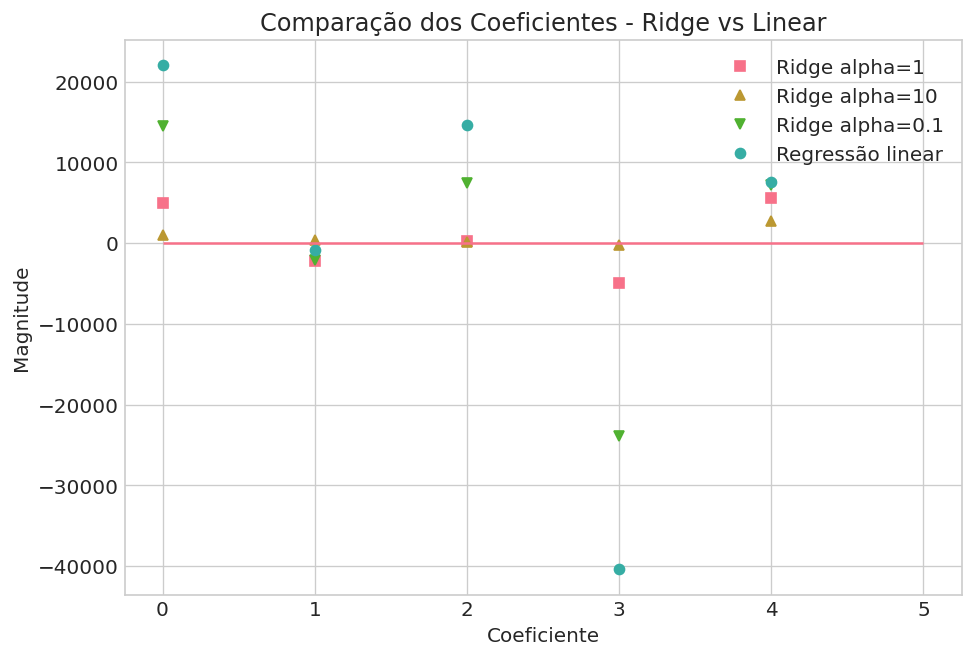

In [ ]:
# Comparação da Regressão linear e Ridge
plt.figure(figsize=(9, 6))
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")
plt.plot(lr.coef_, 'o', label="Regressão linear")
plt.xlabel("Coeficiente")
plt.ylabel("Magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.legend()
plt.title("Comparação dos Coeficientes - Ridge vs Linear")
plt.show()



In [ ]:
# LASSO (Regressão linear com regularização L1)
lasso = Lasso().fit(X_train, y_train)
print("\nLasso alpha=1")
print("Acurácia na base de treinamento: {:.2f}".format(lasso.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(lasso.score(X_test, y_test)))
print("Número de atributos usados: {}".format(np.sum(lasso.coef_ != 0)))

lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print("\nLasso alpha=.01")
print("Acurácia na base de treinamento: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Número de atributos usados: {}".format(np.sum(lasso001.coef_ != 0)))

lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print("\nLasso alpha=.0001")
print("Acurácia na base de treinamento: {:.2f}".format(lasso00001.score(X_train, y_train)))
print("Acurácia na base de teste: {:.2f}".format(lasso00001.score(X_test, y_test)))
print("Número de atributos usados: {}".format(np.sum(lasso00001.coef_ != 0)))



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.570e+09, tolerance: 1.634e+07
  model = cd_fast.enet_coordinate_descent(



Lasso alpha=1
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.03
Número de atributos usados: 4

Lasso alpha=.01
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.02
Número de atributos usados: 5

Lasso alpha=.0001
Acurácia na base de treinamento: 0.03
Acurácia na base de teste: 0.02
Número de atributos usados: 5


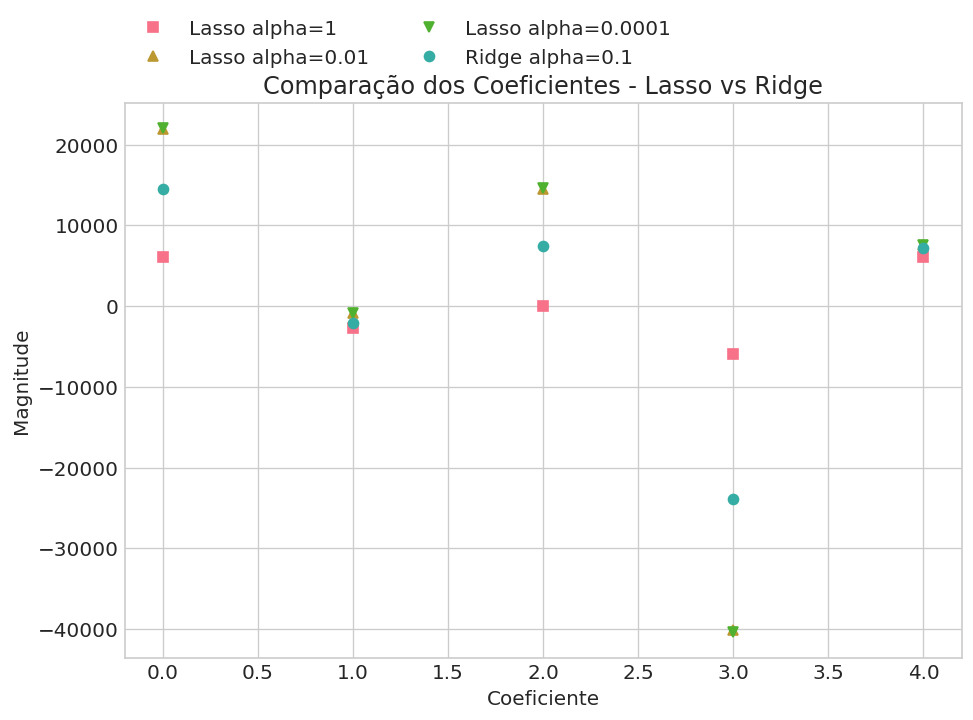

In [ ]:
# Comparação da LASSO e Ridge
plt.figure(figsize=(9, 6))
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")
plt.plot(lasso001.coef_, '^', label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_, 'v', label="Lasso alpha=0.0001")
plt.plot(ridge01.coef_, 'o', label="Ridge alpha=0.1")
plt.legend(ncol=2, loc=(0, 1.05))
plt.xlabel("Coeficiente")
plt.ylabel("Magnitude")
plt.title("Comparação dos Coeficientes - Lasso vs Ridge")
plt.show()



In [ ]:
# Análise adicional: Correlação simples
correlation_matrix = df_filtered[['Salario_Medio', 'PIB_2021_OR', 'IDHM']].corr()
print("\nMatriz de Correlação:")
print(correlation_matrix)


Matriz de Correlação:
               Salario_Medio  PIB_2021_OR      IDHM
Salario_Medio       1.000000     0.147651  0.159017
PIB_2021_OR         0.147651     1.000000  0.737570
IDHM                0.159017     0.737570  1.000000
